# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Описание проекта

**Заказчик**

Сервис по продаже автомобилей с пробегом


**Входные данные**

Исторические данные о технических характеристиках, комплектации и ценах автомобилей в сервисе заказчика

**Задача**

Построить модель предсказания стоимости автомобиля. В качестве критериев подбора лучшей модели использовать качество предсказания, скорость предсказания и время обучения модели

**Цель**

Модель будет использоваться в приложении заказчика, а именно позволит узнать примерную стоимость своего автомобиля. Такой функционал позволит привлечь новых клиентов длы заказчика

**Описание входных данных**

`/datasets/autos.csv` - исторические данные об авто в сервисе заказчика

- `DateCrawled` — дата скачивания анкеты из базы
- `VehicleType` — тип автомобильного кузова
- `RegistrationYear` — год регистрации автомобиля
- `Gearbox` — тип коробки передач
- `Power` — мощность (л. с.)
- `Model` — модель автомобиля
- `Kilometer` — пробег (км)
- `RegistrationMonth` — месяц регистрации автомобиля
- `FuelType` — тип топлива
- `Brand` — марка автомобиля
- `Repaired` — была машина в ремонте или нет
- `DateCreated` — дата создания анкеты
- `NumberOfPictures` — количество фотографий автомобиля
- `PostalCode` — почтовый индекс владельца анкеты (пользователя)
- `LastSeen` — дата последней активности пользователя
- `Price` — цена (евро). **Целевой признак**

In [1]:
!pip install numba==0.57.1 -q
!pip install pingouin -q
!pip install phik -q
!pip install shap==0.44.0 -q
!pip install lightgbm -q
!pip install catboost -q
!pip install scikit-learn --upgrade -q
!pip install pgeocode -q

In [2]:
#
import pandas as pd
import numpy as np
import re
import time
import scipy.stats as st
import warnings

#графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# машинное обучение
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    RobustScaler,
    LabelEncoder
)
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import root_mean_squared_error, r2_score

#
import pgeocode
import phik
import pingouin as pg
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool


RANDOM_STATE=42
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

## Разведочный анализ

In [3]:
def import_and_analyze(path, sep=',', decimal='.', date_cols=True):
    try:
        data = pd.read_csv(path, 
                           sep=',', 
                           decimal ='.', 
                           parse_dates=date_cols, 
                           converters={'PostalCode':str})
    except:
        print('Не удалось открыть файл, проверьте путь')
    
    data.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', x).lower() for x in data.columns]
    
    data.info()
    print(f'\nПолных явных дубликатов - {data.duplicated().sum()}')
    display(data.head())
    
    
    
    stats = {'values' : [
                         'Unique, count',
                         'Unique, %',
                         'Missing, count',
                         'Missing, %'
                        ]}
    for col in data:
        stats[col] = [
                      data[col].nunique(),
                      round(100 * data[col].nunique() / data.shape[0], 2),
                      data[col].isnull().sum(),
                      round(100 * data[col].isnull().sum() / data.shape[0], 2)
                     ]
    stats = pd.DataFrame(stats).set_index('values').T
    display(stats.sort_values('Missing, %', ascending=False))
    
    return data

In [4]:
data_cars= import_and_analyze('/datasets/autos.csv', date_cols=['DateCrawled', 
                                                      'DateCreated', 
                                                      'LastSeen'])

### Вывод

- 354369 записей
- 4 полных явных дубликата
- пропуски
    - `repaired` - 20.1 % - вероятно просто не стали искать / не нашли галочку, что машина не была в ремонте, а может часть мошенников
    - `vehicle_type` - 10.6 % - возможно какие-то пограничные варианты, либо просто не стали указывать
    - `fuel_type` - 9.3 % - аналогично
    - `gearbox` - 5.6 % - аналогично
    - `model` - 5.6 % - аналогично
- уникальные значения - есть неявные дубликаты, например `gasoline` и `petrol` в `fuel_type`
- столбцы с датами сразу импортировали в формате дат - `DateCrawled`, `DateCreated`, `LastSeen`
- стиль названия столбцов сразу поправили

## Подготовка данных

### Предобработка

Выбросим полные дубликаты (4 штуки)

In [5]:
data_cars.drop_duplicates(inplace=True)

Пропуски будем заполнять в пайплайне после исследовательского анализа, пока трудно что-то с ними решить

Проверим признаки с небольшим числом уникальных значений

#### `vehicle_type`

In [6]:
data_cars['vehicle_type'].unique()

Здесь вроде все в порядке, правда выделяется `small`, посмотрим потом на распределении

#### `fuel_type`

In [7]:
data_cars['fuel_type'].unique()

- `petrol` и `gasoline` - это все бензин, объединим их в `petrol` в пайплайне SimpleImputer-ом
- `lpg` и `cng` - сжиженный (пропан) или сжатый (метан) газ, по-хорошему объединять не стоит

In [8]:
data_cars['fuel_type'].where(data_cars['fuel_type']!='gasoline', 
                             other='petrol', 
                             inplace=True)

#### `number_of_pictures`

In [9]:
data_cars['number_of_pictures'].unique()

Почему-то у всех ноль фотографий, этот столбец отбросим

In [10]:
data_cars.drop('number_of_pictures', axis=1, inplace=True)

#### `registration_month`

In [11]:
data_cars['registration_month'].unique()

Есть нулевой месяц, то ли вместо пропуска, то ли еще что, заменим на `nan` пока что

In [12]:
data_cars['registration_month'].where(data_cars['registration_month']!=0, 
                                      other=np.NaN, 
                                      inplace=True)

#### `kilometer`

In [13]:
data_cars['kilometer'].unique()

Видимо, пробег указан как `до x км`, а от значение - ниже, ранжированы короче

#### `brand`

In [14]:
data_cars['brand'].unique()

Тут вроде все в порядке, может какие-то бренды объединить - вроде mini и bmw, потому что один концерн, а в модели скорее всего mini cooper какой-нибудь стоит. Но в моделях пользователи могли заполнять поле сами, а здесь похоже на выбор из категорий

#### `model`

In [15]:
data_cars['model'].unique()

Так и есть - например `rangerover` и `range_rover`, причем дело происходит видимо в Германии - `a_klasse`, посмотрим потом по индексам и брендам. Благодаря немецкой аккуратности, здесь не так много неявных дубликатов

#### `пропуски`

Так как основной упор скорее всего будет на деревьях, то пропуски оставим для них `np.nan` - у деревьев в бустингах хорошая стратегия работы с ними. Для не деревьев заполним скорее всего `unknown`

### Исследовательский анализ

In [16]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

# Определим функцию для графического и описательного анализа столбцов
def describe_column(data, explode=None):

    # Условие на тип диаграммы не категориальной без сравнения:

    if (data.dtype != object):
        fig = plt.figure(figsize=(20,6))

        # Настройки сетки графика
        gs = gridspec.GridSpec(2, 2, height_ratios=[5, 1])
        gs.update(hspace=0)
        ax_hist = plt.subplot(gs[0, 0])
        ax_box = plt.subplot(gs[1, 0])
        ax_qq = plt.subplot(gs[:, 1])

        # Boxplot и гистограмма
        sns.boxplot(x=data, ax=ax_box)
        sns.histplot(x=data,
                     bins='sturges',
                     alpha=1,
                     edgecolor='black',
                     ax=ax_hist,
                     stat='probability')
        plt.subplots_adjust(hspace=0)
        ax_hist.set_ylabel('Частота', size=14)
        ax_hist.set_title(f'Распределение признака {data.name}', size=14)

        # QQ-plot
        pg.qqplot(data, ax=ax_qq, square=False)
        ax_qq.set_title(f'Нормальный график Q-Q признака {data.name}', size=14)
        ax_qq.set_xlabel('Нормальные квантили', size=14)
        ax_qq.set_ylabel('Признаковые квантили', size=14)

        plt.show()

        # Описательная статистика
        display(pd.DataFrame(data.describe()).T)

    # Условие на категориальный тип диаграммы
    else:
        data.value_counts().plot(kind='pie', explode=explode,
                                 autopct=make_autopct(data.value_counts()),
                                 fontsize=12, figsize=(6, 6))
        plt.title(f'Распределение признака {data.name}', fontsize=12)
        plt.ylabel('')

# создадим дополнтильную функцию для вывода количества элементов в блоке для графика pie
# возвращает подпись элемента в % и число
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%\n({v:d})'.format(p=pct,v=val)
    return my_autopct

#### `postal_code`

Сразу проверим почтовый индекс, так будет проще делать некоторые выводы

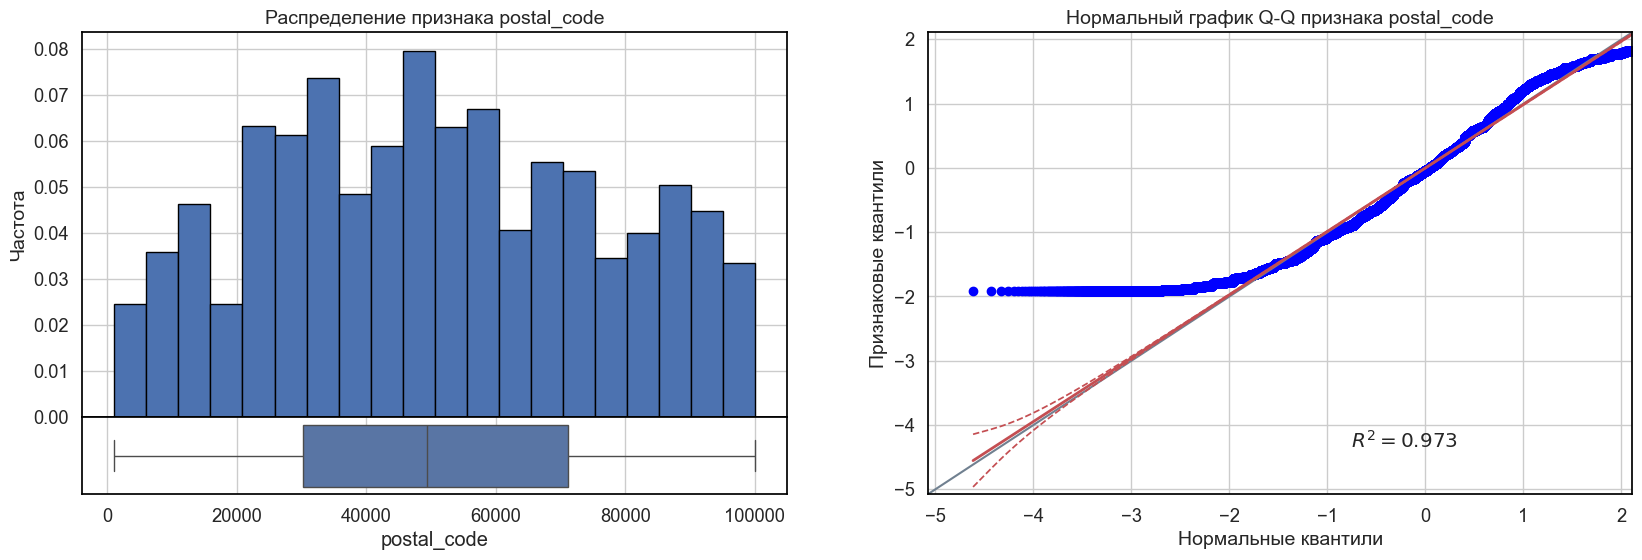

In [17]:
describe_column(data_cars['postal_code'].astype('int'))

Ну да, если погуглить, то по четырем индексам (мин, макс и квартили) так же похоже на Германию. Так что это база данных из Германии. Сам признак использовать не будем, хотя с помощью pgeocode можно было бы создать признак `города`, возможно имел бы какое-то влияние, хотя в Германии цены не сильно зависят от места продажи, так как страна небольшая. А к эксплуатации они более менее одинаково относятся

В Германии 5-значная система кодов, а у нас в данных есть 4-значные, перед ними стоит 0 обычно, просто в системе он опускался при экспорте/импорте, добавим его перед такими объектами в признак

In [18]:
data_cars['postal_code'] = data_cars['postal_code'].apply(lambda x: x if len(x)==5 else '0'+x)

In [19]:
%%time
nomi = pgeocode.Nominatim('de')
data_cars['place'] = nomi.query_postal_code(data_cars['postal_code']).community_name

print('Уникальных областей', data_cars['place'].nunique())
print('Пропусков', data_cars['place'].isna().sum())

Отлично, получилось 397 областей и всего 132 пропуска. Заполним пропуски 'Other', а столбец `postal_code` удалим

In [20]:
data_cars['place'] = data_cars['place'].fillna('Other')
data_cars.drop('postal_code', axis=1, inplace=True)

#### `brand`

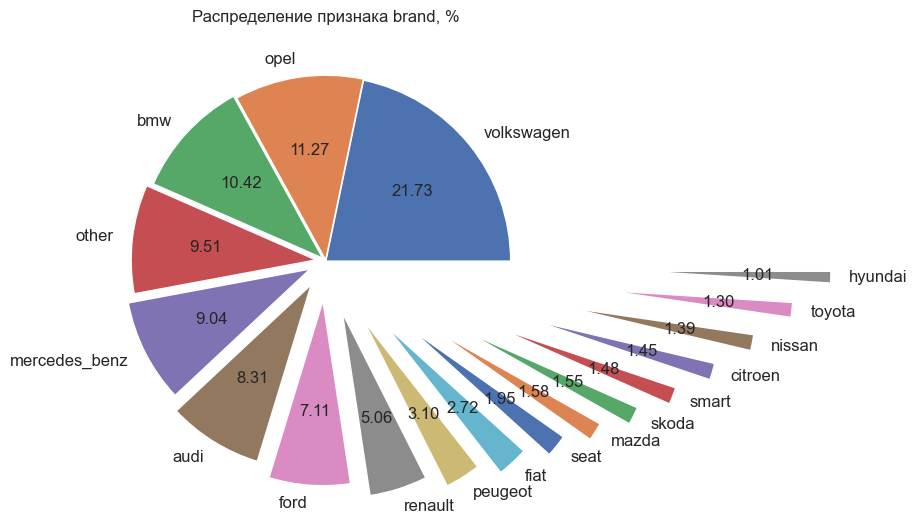

In [21]:
pie_ = (data_cars['brand']
        .value_counts(normalize=True) * 100).to_frame().reset_index()
pie_.loc[pie_['proportion'] < 1, 'brand'] = 'other'
pie_ = pie_.groupby(by='brand')['proportion'].sum().sort_values(ascending=False)
pie_.plot(kind='pie',
         autopct='%.2f',
         explode=[0.006*i**2 for i in range(pie_.shape[0])],
         fontsize=12, figsize=(6, 6))
plt.title(f'Распределение признака brand, %', fontsize=12)
plt.ylabel('');

Ничего особенного, популярные Volkswagen, Opel, BMW похоже на Германию

#### `price`

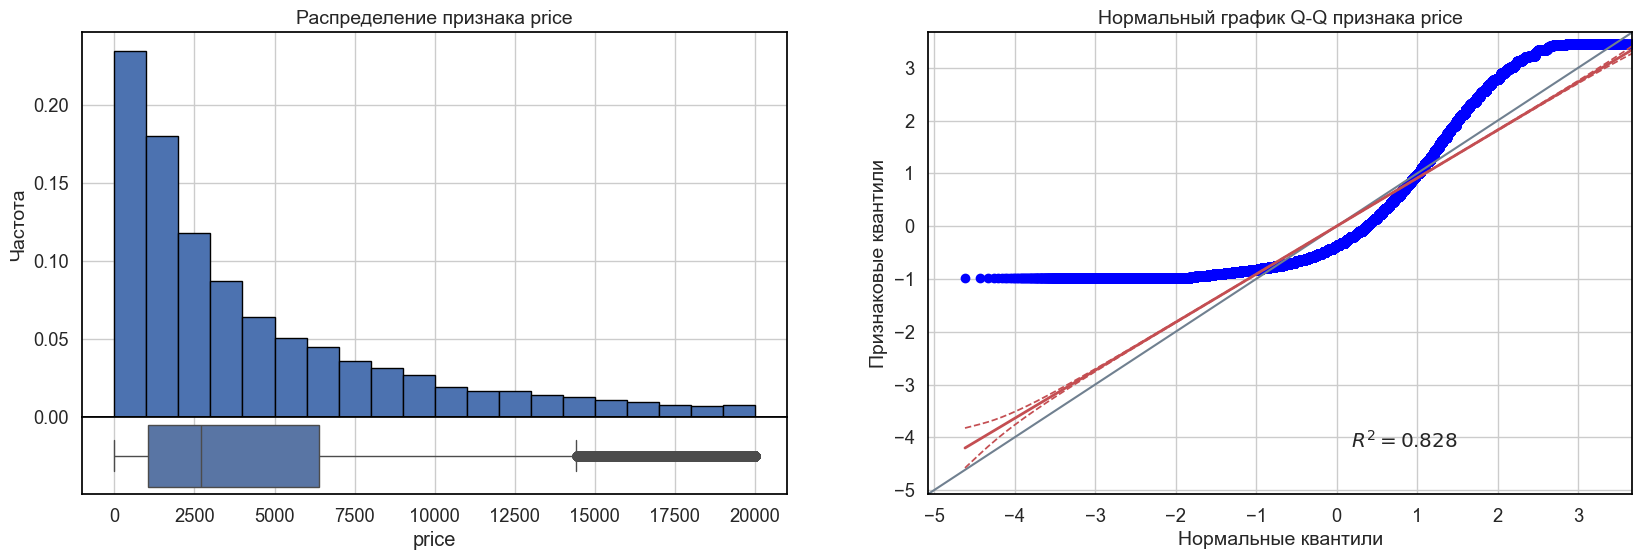

In [22]:
describe_column(data_cars['price'])

Так как дело происходит в Германии, то цена в евро. Цена в 0 евро выглядит странно, а так же за какие-нибудь 10 евро, может быть совсем убитые автомобили, которые годятся только на металл. Вот пример цен на поддержанные авто в Германии в 2015 году

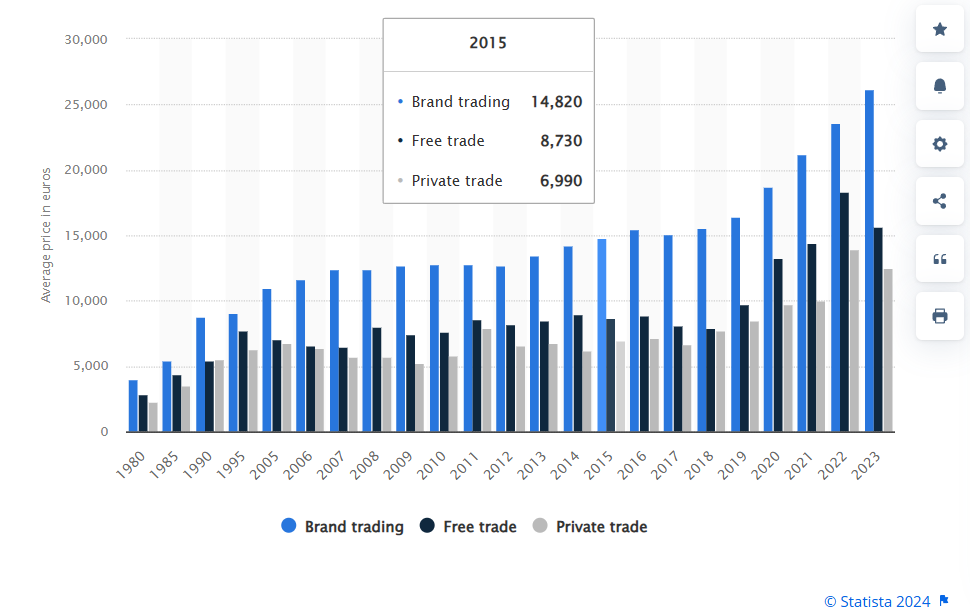

Посмотрим на распределение логаифма признака, так как распределение логнормальное

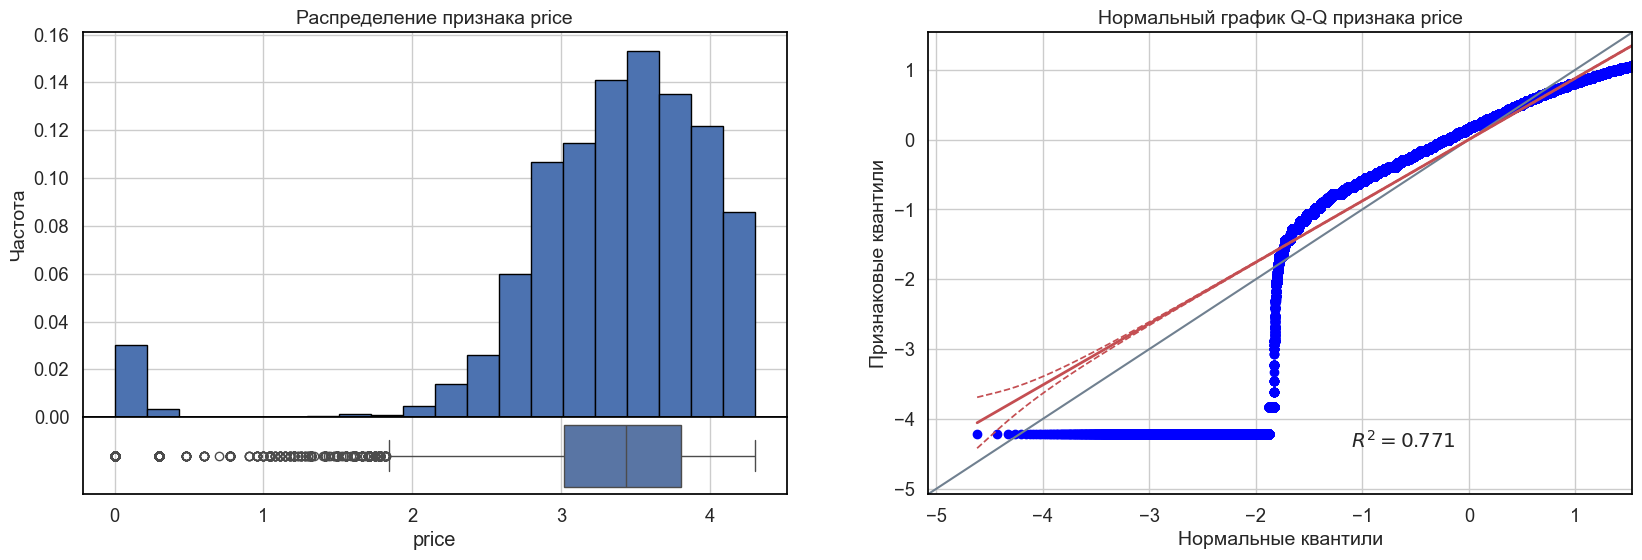

In [23]:
describe_column(np.log10(data_cars['price']+1))

Много объектов, почти 3 %, у которых цена меньше 10 евро. Понятно, что где-то должен быть минимум у цен на поддержанных авто, причем они должны быть на условном ходу, то есть явно больше 100 евро. По графику как раз где-то там и заканчиваются выбросы. Тогда и примем его за адекватную границу. За 100 евро в теории в 2016 году можно было взять старую малолитражку с очень большим пробегом, к примеру

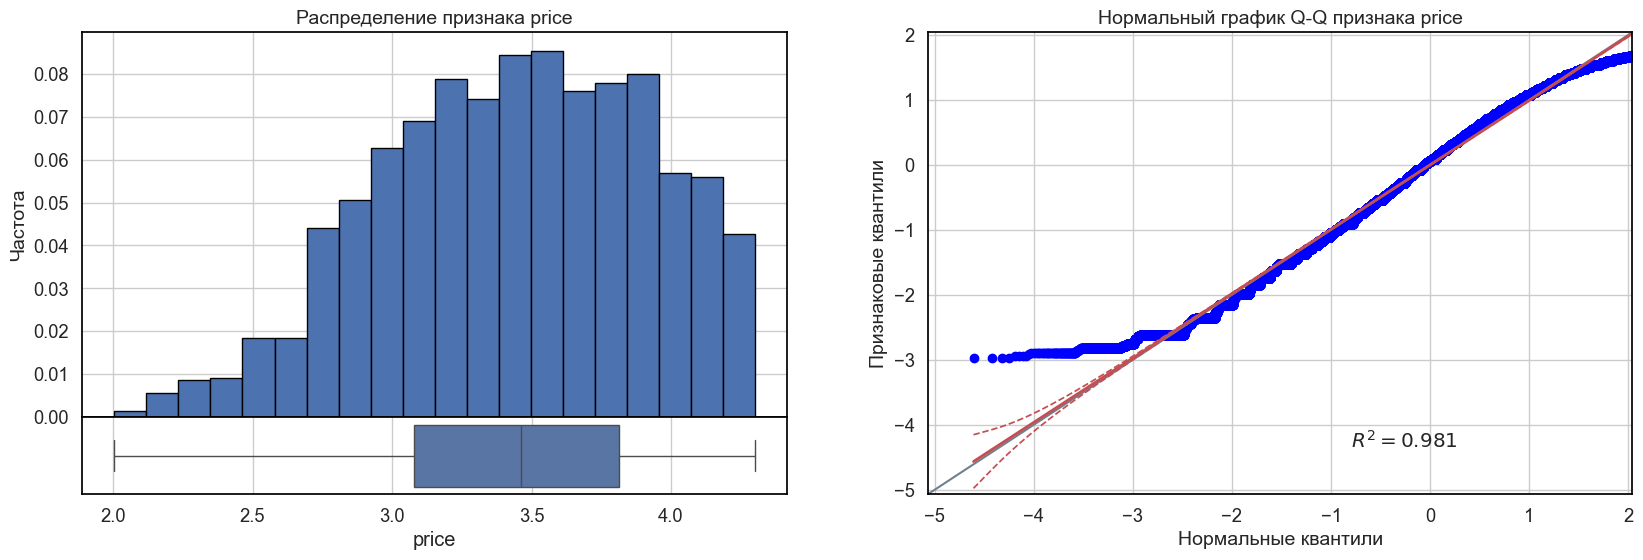

In [24]:
describe_column(np.log10(data_cars.query('price > 100')['price']))

In [25]:
data_cars = data_cars.query('price > 100').reset_index(drop=True)

- Так как это целевой признак, просто уберем все выбросы (14300 записей), основная масса пользователей с более менее живыми автомобилями
- Распределение выглядит логнормальным, у логарифма признака есть смещение вправо

#### `last_seen` и `date_crawled`

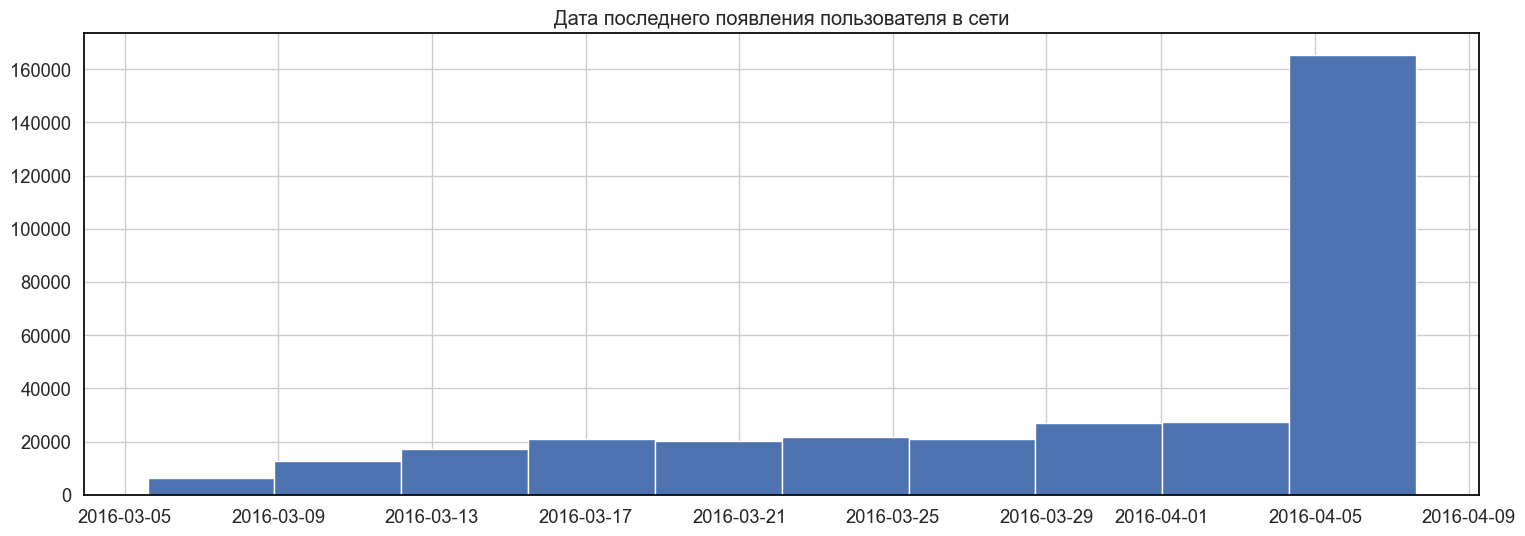

In [26]:
fig = plt.figure(figsize=(18,6))
data_cars['last_seen'].hist()
plt.title('Дата последнего появления пользователя в сети');

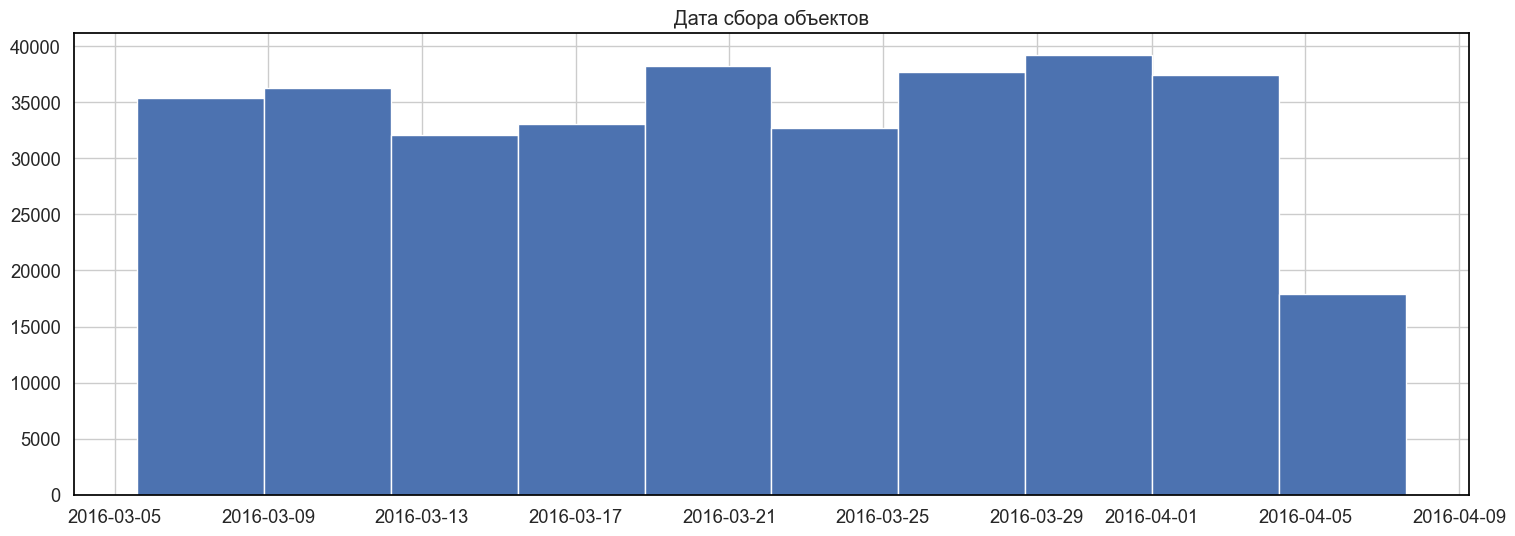

In [27]:
fig = plt.figure(figsize=(18,6))
data_cars['date_crawled'].hist()
plt.title('Дата сбора объектов');

Ничего особенного, признаки использовать не будем, на цену они никакого влияния не оказывают

In [28]:
data_cars.drop(['date_crawled', 'last_seen'], axis=1, inplace=True)

#### `date_created`

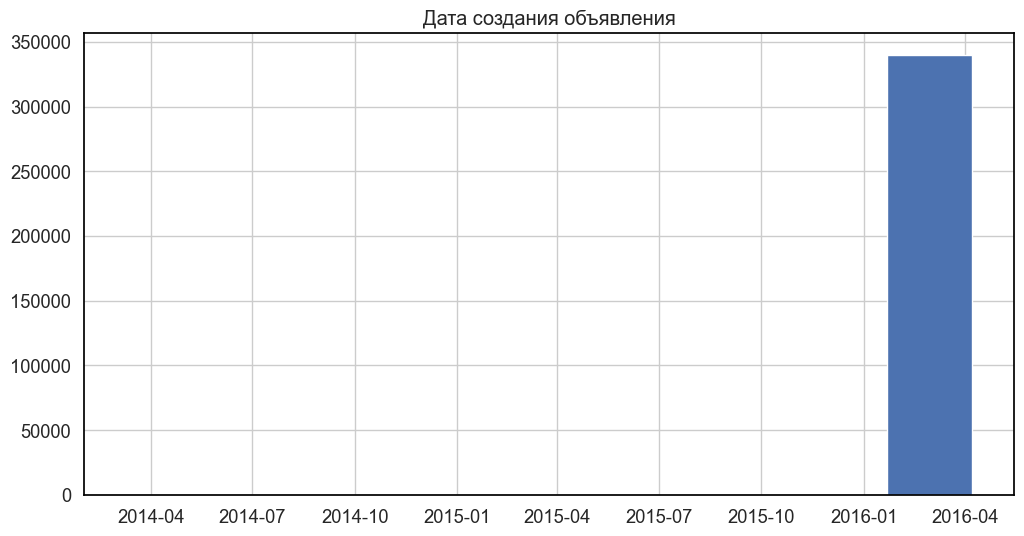

In [29]:
fig = plt.figure(figsize=(12,6))
data_cars['date_created'].hist()
plt.title('Дата создания объявления');

Почти все объявления были созданы в марте 2016, ограничим выборку убрав все объявления до февраля 2016 года

In [30]:
data_cars.query('date_created < "2016-02"')['date_created'].count()

In [31]:
data_cars = data_cars.query('date_created > "2016-02"').reset_index(drop=True)

Удалили 95 выбросов по дате создания объявления до февраля 2016 года

Сам столбец тоже удалим, так как у нас он по сути является константой `2016-03-01` в пределах 1.5 месяцев. Если захотим добавить дополнительный признак, вроде количества лет или месяцев с даты регистрации автомобиля, то просто воспользуемся этой датой

In [32]:
data_cars.drop('date_created', axis=1, inplace=True)

#### `registration_year` и `registration_month`

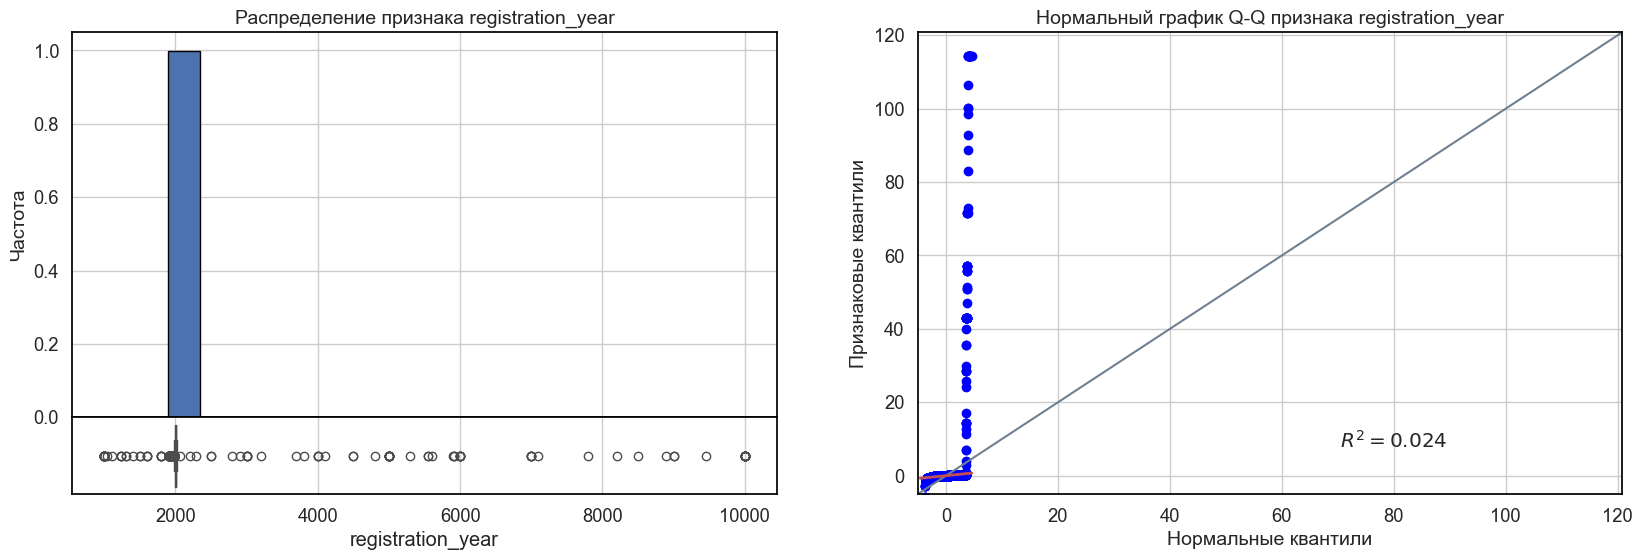

In [33]:
describe_column(data_cars['registration_year'])

- Явно стоит ограничить сверху 2016 годом включительно, так как дата создания объявления у нас март 2016
- Так же стоит ограничить снизу, нижней границей будет 1980, так как до этого уж совсем раритет и его процент довольно мал

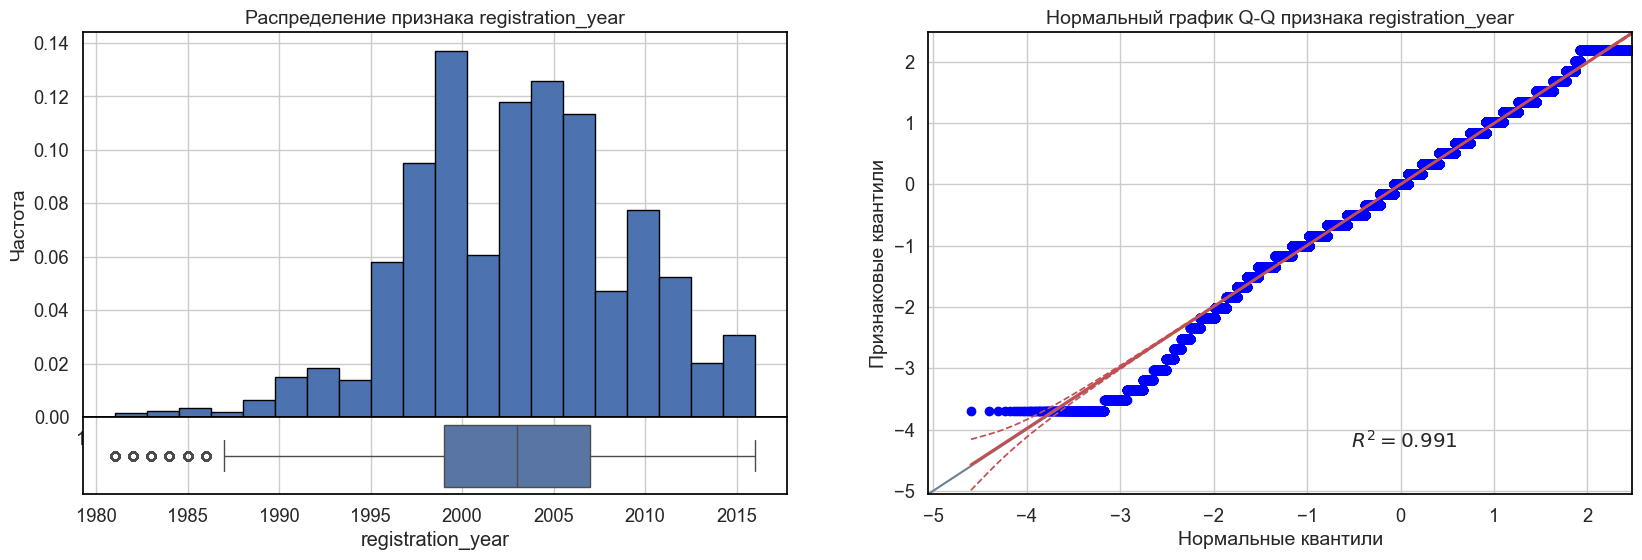

In [34]:
describe_column(data_cars.query('1980 < registration_year < 2017')['registration_year'])

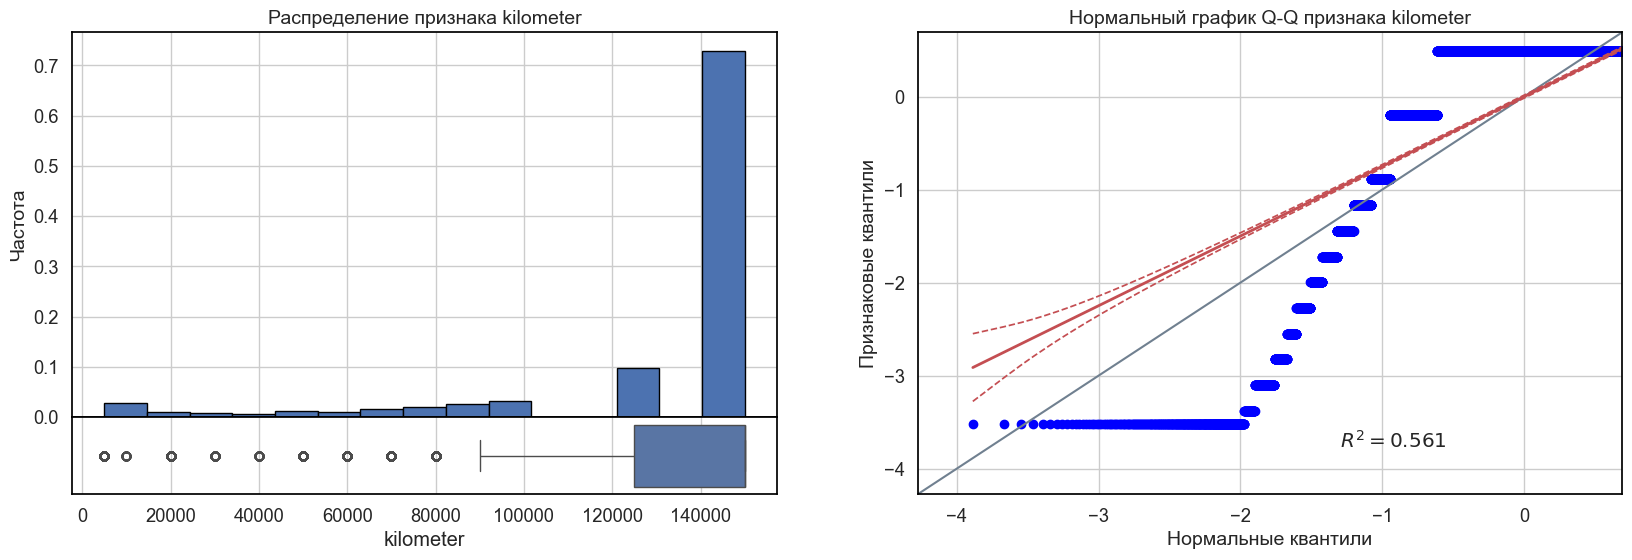

In [35]:
describe_column(data_cars.query('registration_year >= 2017')['kilometer'])

Вылетает 17 тыс объектов, но что поделать, не бьется с датой выгрузки, надо было бы уточнить этот момент, так как машина теряет в цене сильно с возрастом, признаки сильно связаны, в текущих условиях рисковать не хочется. Причем у большей части пробег больше 150к км

In [36]:
data_cars = data_cars.query('1980 < registration_year < 2017').reset_index(drop=True)

Распределение более менее похоже на нормальное

Очевидно, что от месяца регистрации цена не зависит (хоть в марте, хоть в январе), но можно с большей точностью построить возраст автомобиля, может полгода или квартал

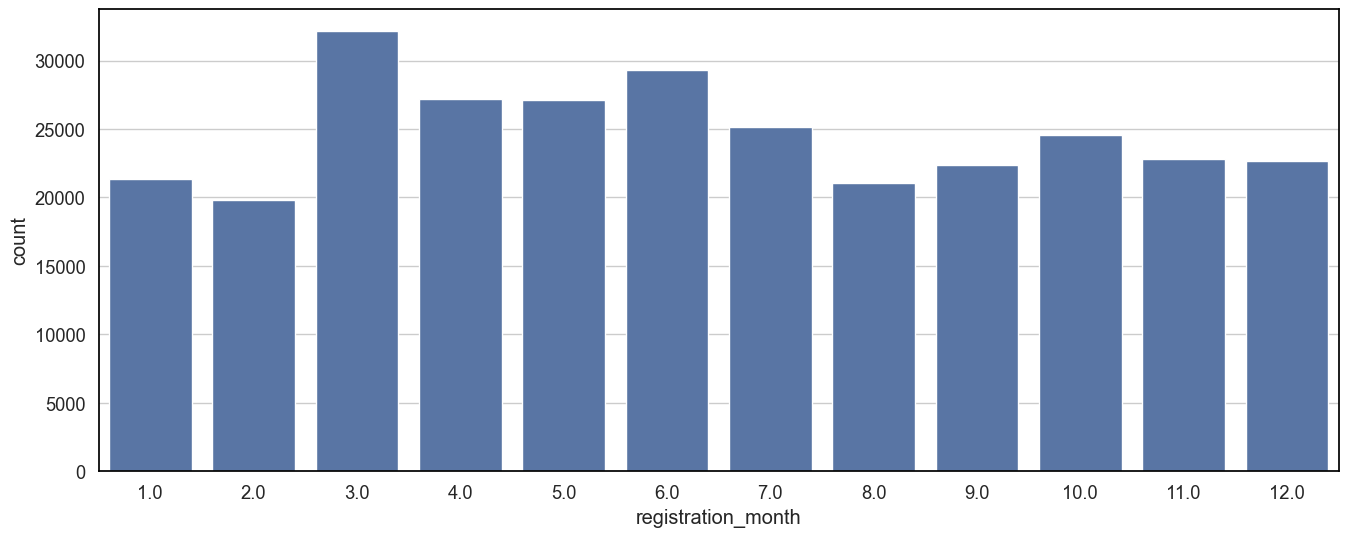

In [37]:
fig = plt.figure(figsize=(16,6))
sns.countplot(x=data_cars['registration_month'], color='b');

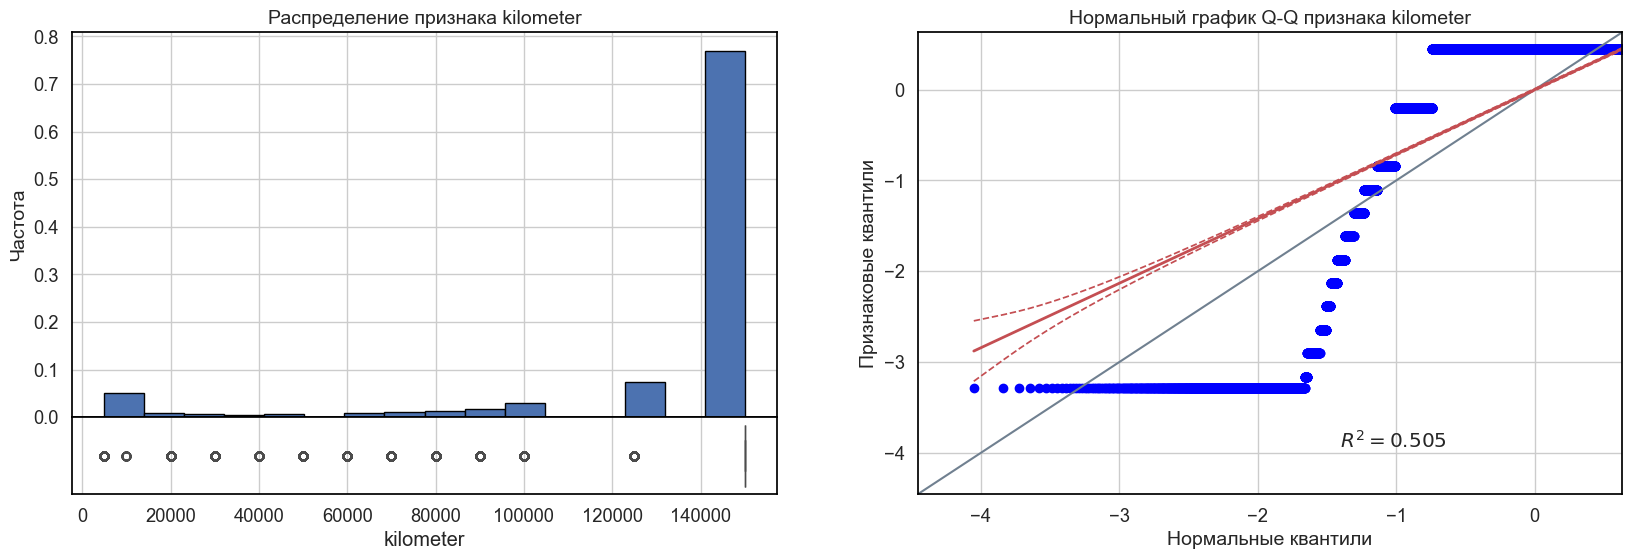

In [38]:
describe_column(data_cars.query('registration_month.isna()')['kilometer'])

- 26 тыс. записей без месяца, можно либо вообще его не использовать, либо заполнить случайно из распределения месяцев в нашей выборке. Смысл месяцы имеют, если автомобиль не старше 2-3 лет.
- Заполним случайно из выборки, а затем посчитаем разницу с датой выгрузки в кварталах, так снизим ошибку такого подхода

In [39]:
np.random.seed(42)
reg_month_ = data_cars['registration_month'].dropna()
data_cars['registration_month'] = (data_cars['registration_month']
    .apply(lambda x: np.random.choice(reg_month_) if np.isnan(x) else x))

Теперь выбросим все записи с регистрацией старше апреля 2016 года, так как последние объявления были за начало апреля 2016

In [40]:
data_cars.query('registration_year==2016 & registration_month > 4')['price'].count()

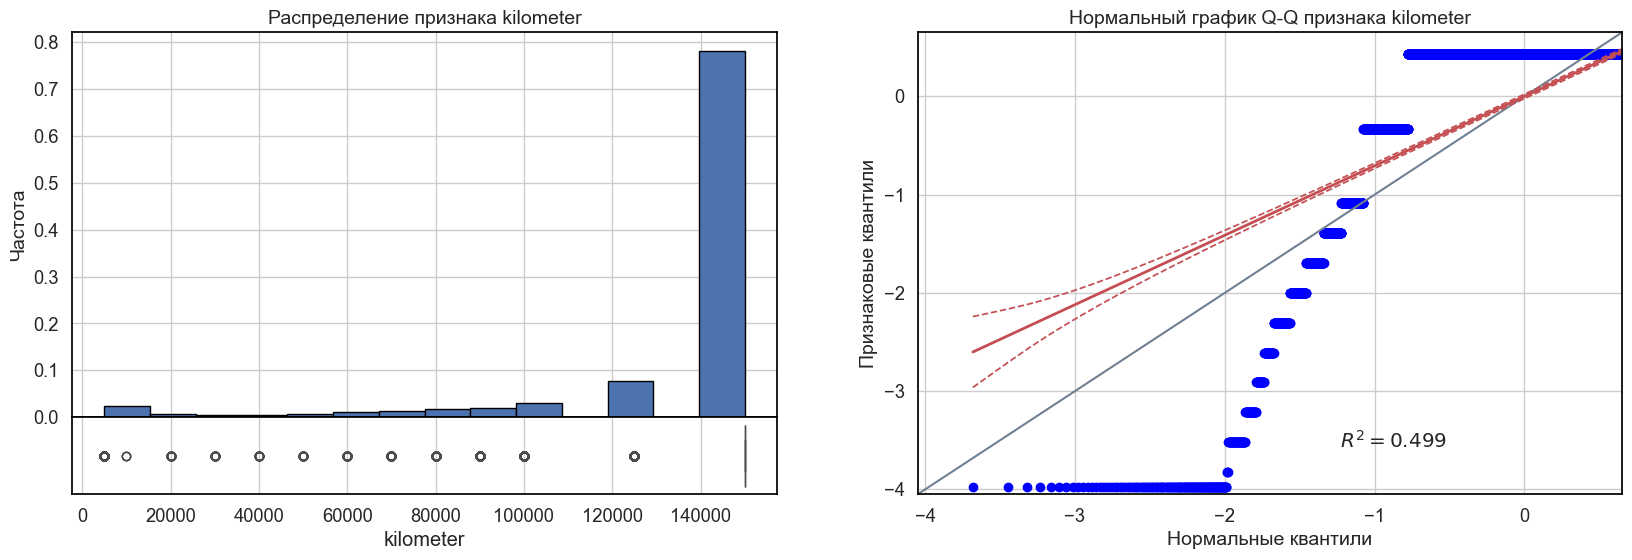

In [41]:
describe_column(data_cars.query('registration_year==2016 & registration_month > 4')['kilometer'])

- 80 процентов с пробегом больше 150000, так что не новые, и не битые, какой смысл имеют непонятно с регистрацией в будущем

Еще минус шесть тысяч, но опять же, скорее всего новые автомобили из салона или что-то вроде того, а логика по связи год регистрации и стоимости остается та же

In [42]:
data_cars = data_cars.query('~(registration_year==2016 & registration_month > 4)').reset_index(drop=True)

Теперь добавим дополнительные признаки `age_years`, `age_quart` и после удалим признак месяца

In [43]:
data_cars['age_month'] = (pd.to_datetime('2016-03-01', format='%Y-%m-%d') - \
                          pd.to_datetime(dict(year=data_cars['registration_year'], 
                                              month=data_cars['registration_month'], 
                                              day=1))
                         ).dt.days / 30.44

data_cars['age_month'] = round(data_cars['age_month'])

In [44]:
data_cars.drop('registration_month', axis=1, inplace=True)

#### `gearbox` и `repaired`

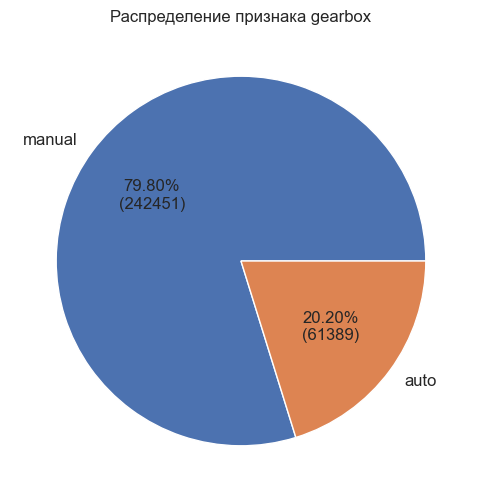

In [45]:
describe_column(data_cars['gearbox'])

Тут ничего особенного, 80 % на ручной коробке передач, 20 - на автомате

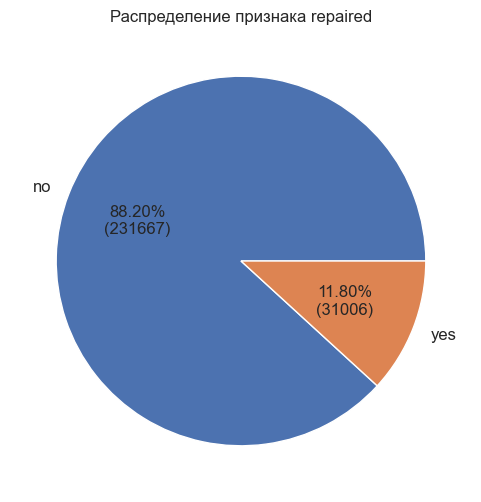

In [46]:
describe_column(data_cars['repaired'])

Тоже ничего особенного 88 % не бывали в серьезных авариях, а 12 % - после восстановления



Для не бустинговых моделей пропуски заменим на `unknown`, так как не до конца уверены в том, что пользователь просто пропустил пункт, так как его машина была, например, в незначительной аварии с последующим ремонтом, например бампера. Или не стали выбирать коробку передач, так как бывает полуавтомат. Хотя это и дотошные немцы

#### `vehicle_type`

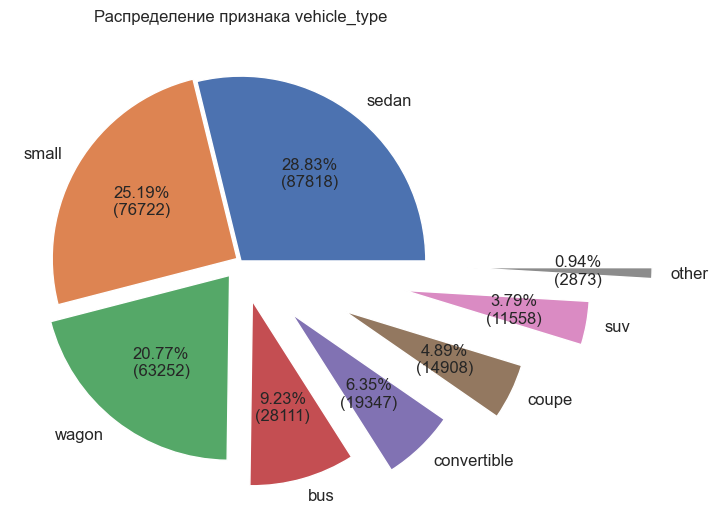

In [47]:
describe_column(data_cars['vehicle_type'], 
                explode=[0.025*i**2 for i in range(data_cars['vehicle_type'].nunique())])

- Тут как-то объединять категории не будем
- `Small` это скорее всего небольшие автомобили популярные в Европе, по размеру короче, чем седан, так что тоже оставим как есть
- Заполним пропуски позже

#### `fuel_type`

In [48]:
(data_cars['fuel_type'].value_counts(normalize=True)*100).to_frame()

- 98 % на бензиновых двигателях, 1.65 % на сжиженном газе, далее совсем маленький процент
- Заполним пропуски позже

#### `model`

In [49]:
(data_cars['model'].value_counts(normalize=True)*100).to_frame().head(10)

- 98 % на бензиновых двигателях, 1.65 % на сжиженном газе, далее совсем маленький процент
- Заполним пропуски позже

#### `power`

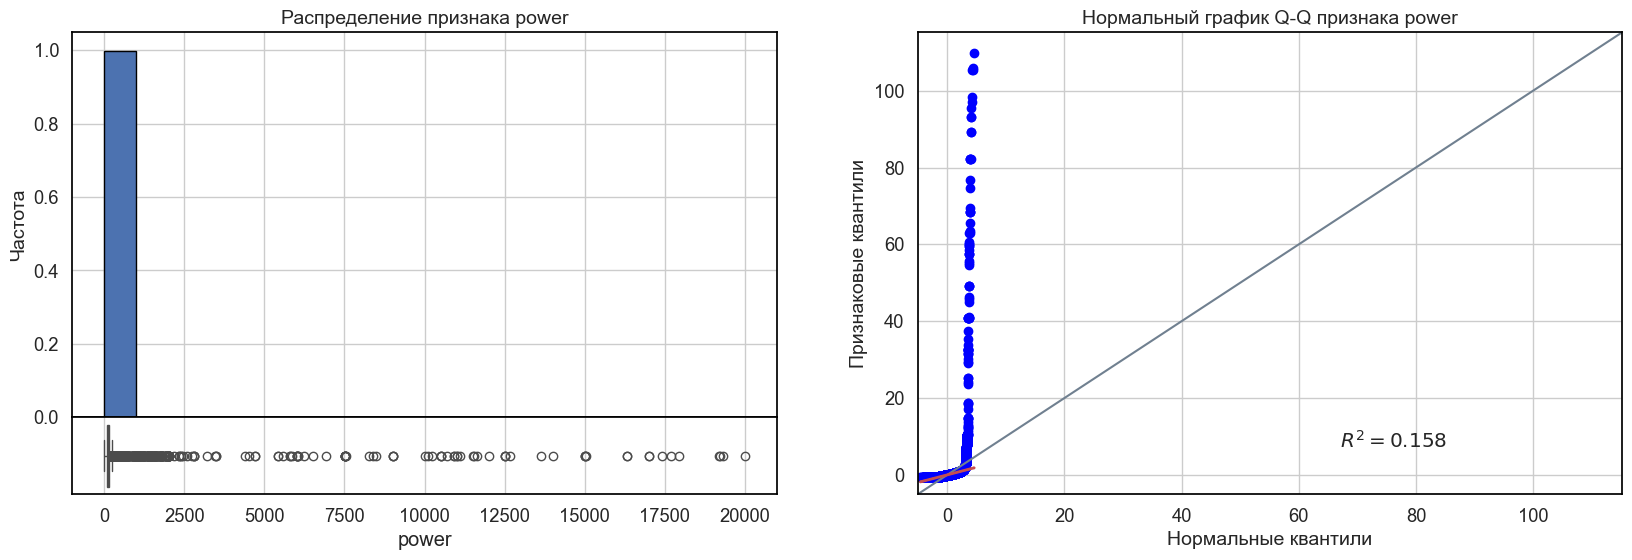

In [50]:
describe_column(data_cars['power'])

Сверху ограничимся 1000 л.с., что-то около такого у Теслы максимальное

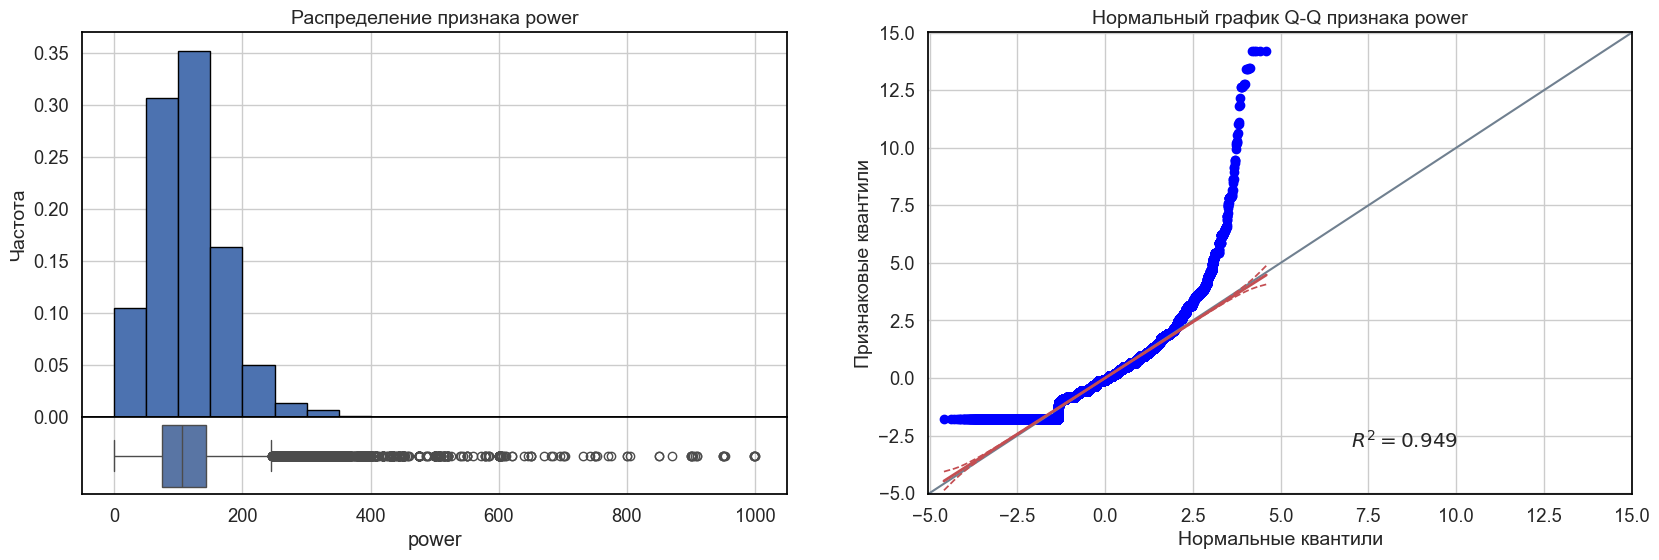

In [51]:
describe_column(data_cars.query('power<=1000')['power'])

In [52]:
data_cars = data_cars.query('power<=1000').reset_index(drop=True)

In [53]:
data_cars.query('power<35')['power'].count()

Границей снизу возьмем 35 л.с. (потому что минималка, что есть это 38 л.с. на 22 год, а до этого могли быть чуть послабее), а все что ниже особенно большой процент нулей обработаем с помощью связки столбцов `brand`, `model`, `vehicle_type` и `registration_year` и заполним медианным значением, если это будет возможно, так как таких объектов аж 31 тыс. - почти 10 %

In [54]:
data_cars['power_med'] = (data_cars
                          .replace({'power' : np.arange(0, 36, 1)}, np.nan)
                          .groupby(['brand', 
                                    'model', 
                                    'vehicle_type', 
                                    'registration_year'
                                   ], dropna=False)['power']
                          .transform('median'))

In [55]:
data_cars['power'] = data_cars.apply(lambda x: 
                                     x['power'] if x['power'] > 35 else x['power_med'], 
                                     axis=1)
data_cars.drop('power_med', axis=1, inplace=True)

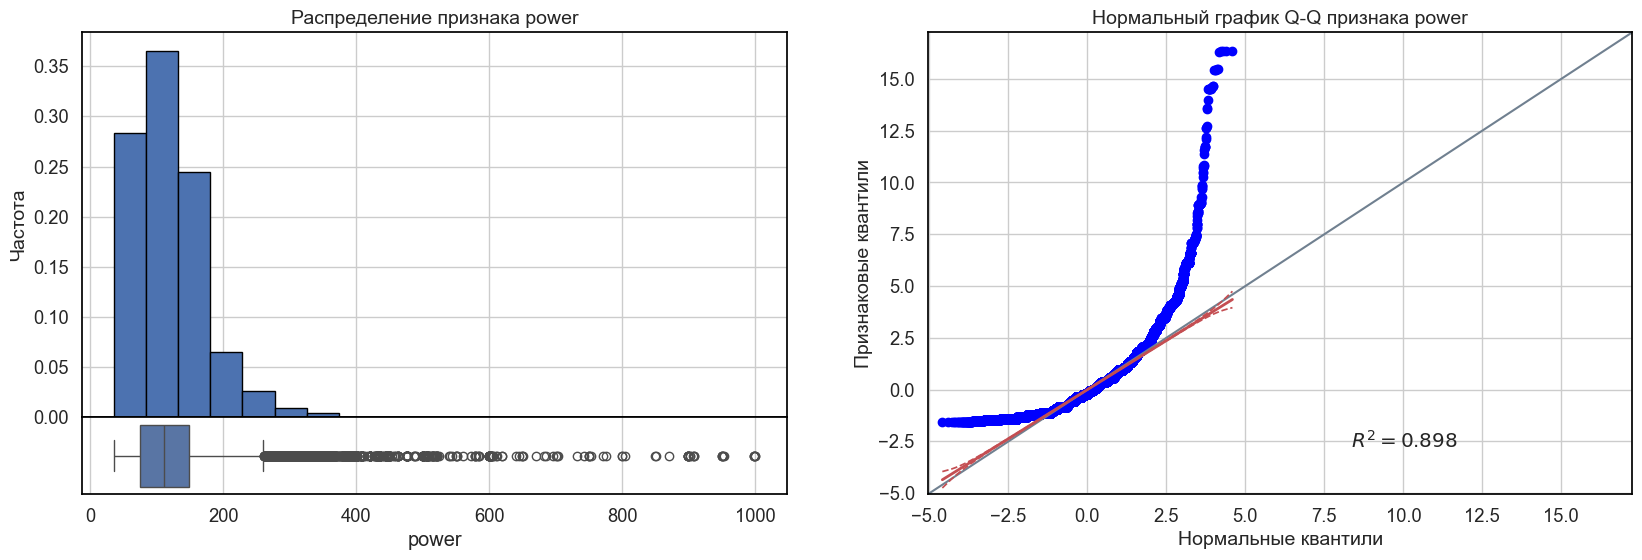

In [56]:
describe_column(data_cars['power'])

Большую часть заполнили максимально точно, осталось 2200 записей, в которых есть пропуск в модели или типе кузова (или `other`). Можно было бы взять медиану по без типа кузова, например, попутно исключив модель `other` и опять более менее нормально заполнить, но выигрыш был бы небольшим процентом от 2200 и по сравнению с 320 тыс это не стоит времени, поэтому просто выбросим 0.7 %, тем более, что там есть пропуски и в других полях

In [57]:
data_cars.dropna(subset='power', inplace=True)
data_cars.reset_index(drop=True, inplace=True)

Распределение похоже на нормальное со сдвигом влево, хотя в теории ближе к логнормальному, может стоило ограничить сверху 1000 л.с.

#### `kilometer`

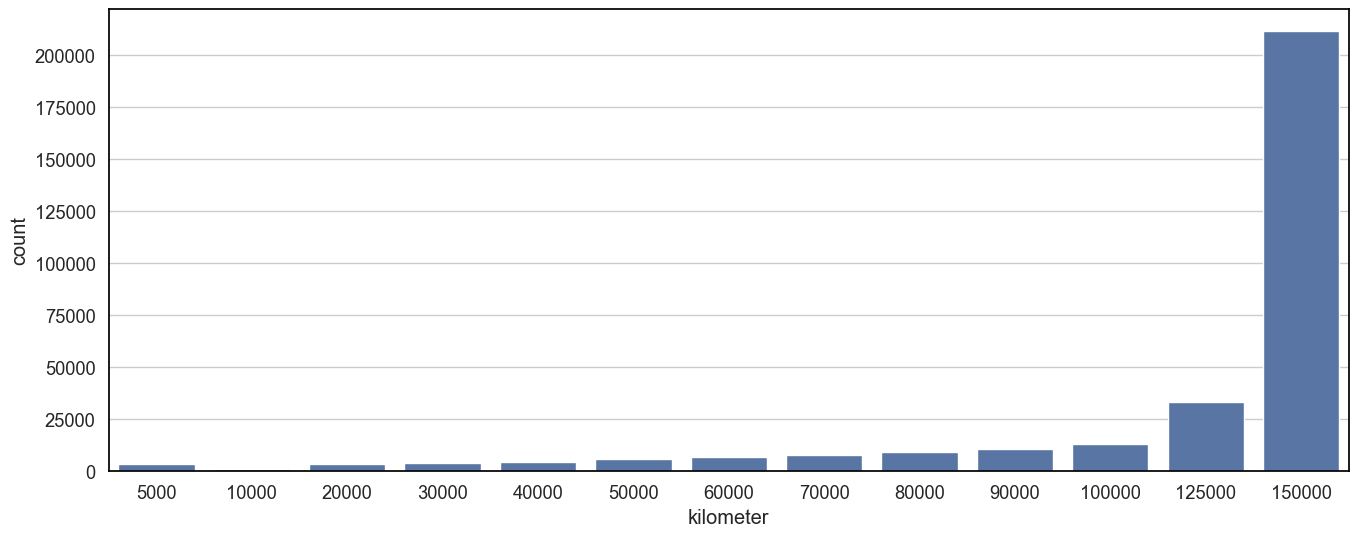

In [58]:
fig = plt.figure(figsize=(16,6))
sns.countplot(x=data_cars['kilometer'], color='b');

Ничего необычного, ранжированный признак (до 5 тыс км, ..., более 150 тыс км)

#### Заполнение пропусков в `model`, `vehicle_type`, и `fuel_type`

Заполним пропуски с помощью RandomForestClassifier

In [59]:
categorical = ['model', 'vehicle_type', 'brand']
d={}

# Создадим словарь из энкодеров и закодируем признаки без заполнения пропусков
for col in categorical:
    d[col] = LabelEncoder().fit(data_cars.loc[data_cars[col].notnull(), col])
    
    # ставим other на первое место, чтобы потом можно было кодировать в начальном приближении 0
    if col != 'brand':
        vals_ = sorted(data_cars[col].dropna().unique())
        vals_.insert(0, vals_.pop(vals_.index('other')))
        d[col].classes_ = np.array(vals_)

# Кодируем признаки без np.nan
for col in categorical:
    data_cars.loc[data_cars[col].notnull(), col] = d[col].transform(data_cars.loc[data_cars[col].notnull(), col])

In [60]:
imp_cat = IterativeImputer(estimator=RandomForestClassifier(random_state=RANDOM_STATE), 
                           initial_strategy='constant', 
                           fill_value=0,
                           max_iter=6, 
                           random_state=RANDOM_STATE,
                           skip_complete=True, 
                           tol=0.01,
                           verbose=20)

In [61]:
%%time
data_cars[categorical] = imp_cat.fit_transform(data_cars[categorical])

In [62]:
for col in categorical:
    data_cars[col] = d[col].inverse_transform(data_cars[col].astype(int))

### Корреляционный анализ

In [63]:
interval_cols = ['price']
corr_matrix = data_cars.phik_matrix(interval_cols=interval_cols)

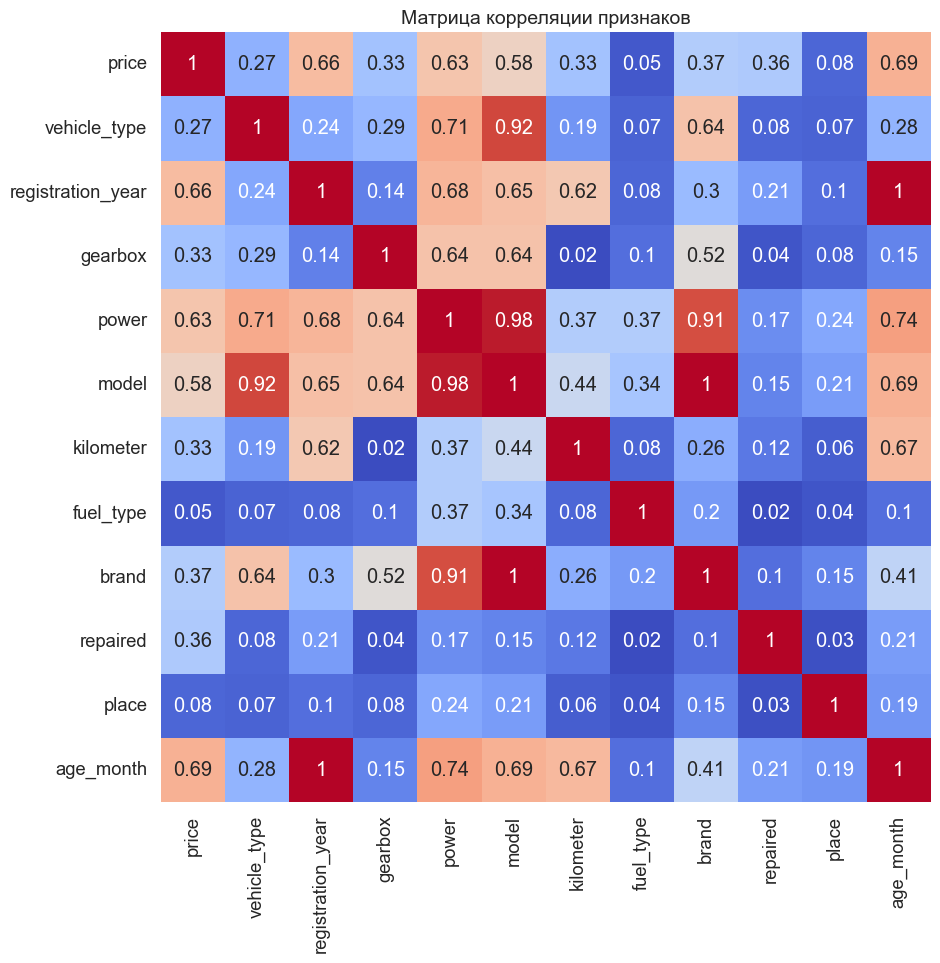

In [64]:
plt.figure(figsize=(10, 10))
plt.title('Матрица корреляции признаков',
          fontsize=14)
sns.heatmap(corr_matrix.round(2), 
            annot = True, square=True, 
            cmap='coolwarm', 
            cbar=False);

- Есть сильная мультиколлинеарность между брендом, моделью и мощностью двигателя, логичная корреляция
- Возраст в месяцах и год регистрации естесственно сильно мультиколлинеарны
- Они нам не помешают, так как основными моделями будут из семейства деревьев
- Цена автомобиля ожиадемо сильно коррелирует с возрастом авто, мощностью двигателя и моделью

In [65]:
# VIF анализ
cols_= [
    'price',
    'power',
    'registration_year',
    'age_month'
]

df_ = add_constant(data_cars.reset_index())

vif_data = pd.DataFrame()
vif_data['feature'] = df_[cols_].columns
vif_data['VIF'] = [variance_inflation_factor(df_[cols_].values, i) 
                          for i in range(len(df_[cols_].columns))]
vif_data

По вариации дисперсии есть немного большие значения для возраста и года регистрации, но опять же, для деревьев это не представляет проблемы

### Вывод

- Выбросили 4 полных дубликата
- Выбросили столбец `number_of_pictures` так как все значения 0
- В `fuel_type` объединили `petrol` и `gasoline` в `petrol`, так как это одно и то же
- Признак `postal_code` заменили на `place` с 397 уникальными областями Германии с помощью `pgeocode`
- По целевому признаку `price` убрали 14300 записей с ценой авто менее 100 евро
- `last_seen` и `date_crawled` выбросили ввиду отсутствия значимости
- По `data_created` убали 95 выбросов, сам признак также удалили ввиду малоинформативности
- 26 тыс. пропусков в `registration_month` (когда месяц был 0) заполнили случайными значениями от 1 до 12
- По `registration_year` и `registration_month` выбросили около 19 тыс. объектов после апреля 2016 года, так как на эту дату происходила выгрузка. Убрали объекты до 1980 года, так как в зоне ретро авто. Добавили `age_month` как возраст авто в месяцах. `registration_month` удалили
- Мощность двигателя `power` ограничили сверху 1000, а снизу 35 л.с. Около 29 тыс. пропусков (0 значений) заполнили медианой с помощью группировки по `brand`, `model`, `vehicle_type`, `registration_year`. Около 2000 записей выбросили, так как не нашлось полных групп
- Пропуски (около 50 тыс. суммарно) в `model`, `vehicle_type`, и `fuel_type` заполнили с помощью `MissForest` подхода через `IterativeImputer` и `RandomForestClassifier`
- Итого осталось 314 тыс. записей от 354 тыс. Около 35 тыс. выброшенных записей так или иначе были сильно связаны с целевым признаком и не представляли возможным точно определить ошибочность их значений

## Обучение моделей

Для бустингов и ансамбля количество гиперпараметров минимально, чтобы занимало адекватное время в тренажере. Локально через RandomizedSearchCV нашел подходящие гиперпараметры. Ну и время соответственно зависит от ресурсов

In [66]:
data_cars = data_cars.apply(lambda x: x.astype('category') if x.dtype=='O' else x)

In [67]:
X = data_cars.drop(['price'], axis=1)
y = data_cars['price']

ord_cols = [
    'vehicle_type',
    'model',
    'fuel_type',
    'brand',
    'place'
]

ohe_cols = [
    'gearbox',
    'repaired'
]

num_cols = [
    'registration_year',
    'power',
    'age_month',
    'kilometer'
]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE)

Подготовим функцию для обучения и сбора статистики по лучшей модели


Будем обучать четыре вида моделей: 
- Линейная регрессия
- Дерево решений
- Случайный лес
- Градиентный Бустинг
    - LGBM
    - CatBoost

In [68]:
def model_search(model_search, param_search, name):
    
    model = GridSearchCV(
        model_search,
        param_search,
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    model.fit(X_train, y_train)
    
    start = time.time()
    for i in range(3):
        y_pred =  model.best_estimator_.predict(X_train)
    end = time.time()
    predict_time = round((end-start)/3, 2)
    
    print(f'Метрика RMSE лучшей {name} модели по результатам ' 
          f'кросс-валидации: {-round(model.best_score_, 1)}')
    print(f'Время обучения лучшей модели: {round(model.refit_time_, 2)} секунд')
    display(model.best_estimator_)
    
    res = y_train-y_pred
    ci = st.norm.interval(confidence=0.95, 
                          loc=np.mean(res), 
                          scale=np.std(res))
    results = {'model': name,
               'train_rmse' : -round(model.best_score_, 1),
               'train_r2' : round(r2_score(y_train, 
                                           model.best_estimator_.predict(X_train)), 3),               
               'fit_time': round(model.refit_time_, 2),
               'predict_time': predict_time,
               'mean_residual': np.round(np.mean(res), 1),
               'residuals_95%_CI': np.round(np.array(ci))}
    
    return model.best_estimator_, y_pred, results

In [69]:
# OHE
ohe_pipe = Pipeline([
    (
        'imputer_before', 
         SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')
    ),
    (
        'ohe',
        OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False)
    )
])

# ORD
ord_pipe = Pipeline([
    (
        'imputer_before', 
         SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='other')
    ),
    (
        'ord',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    ),
    (
        'imputer_after', 
         SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    )    
])

#NUM
num_pipe = Pipeline([
    (
        'num_imputer_before', 
         SimpleImputer(missing_values=np.nan, strategy='median')
    ),
    (
        'scaler',
        'passthrough'
    )
])

# Preprocessor = CAT + ORD + NUM
preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_cols),
        ('ord', ord_pipe, ord_cols),
        ('num', num_pipe, num_cols)
    ],
    remainder='passthrough')

# Logtransform target, но для Ridge нужно логарфмировать power
logtransformer = TransformedTargetRegressor(regressor=Ridge(),
                                            func=np.log, 
                                            inverse_func=np.exp)

# Preprocessor + Models
pipe_search = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('models', logtransformer)
    ])

### Ridge

In [70]:
%%time
ridge_param = {
             'models': [Ridge()],
             'models__random_state': [RANDOM_STATE],
             'models__max_iter' : [3000],
             'models__alpha' : [0.01, 0.1, 1],
             'preprocessor__num__scaler': [StandardScaler(), RobustScaler()]
              }
model_ridge, y_pred_ridge, res_ridge = model_search(pipe_search, 
                                                    ridge_param, 
                                                    'Ridge')

### DecisionTree

In [71]:
%%time
decision_tree_param = {
                       'models': [DecisionTreeRegressor()],
                       'models__random_state': [RANDOM_STATE],
                       'models__criterion' : ['friedman_mse'],
                       'models__max_depth': np.arange(8, 21, 2),
                       'models__min_samples_leaf': np.arange(6, 19, 6)
                      }
model_tree, y_pred_tree, res_tree = model_search(pipe_search, 
                                                 decision_tree_param, 
                                                 'DecisionTree')

### RandomForest

In [72]:
%%time
random_forest_param = {
                       'models': [RandomForestRegressor()],
                       'models__random_state' : [RANDOM_STATE],
                       'models__n_estimators' : [300],
                       'models__criterion' : ['friedman_mse'],
                       'models__max_features' : [4], 
                       'models__max_depth': [16]
                      }
model_forest, y_pred_forest, res_forest = model_search(pipe_search, 
                                                       random_forest_param, 
                                                       'RandomForest')

### LGBM

In [73]:
%%time
LGBMRegressor_param = {
                       'random_state': [RANDOM_STATE],
                       'objective': ['rmse'],
                       'colsample_bytree': [0.5],
                       'max_depth': [0],
                       'n_estimators': [500],
                       'learning_rate': [.1],
                       'reg_lambda' : [2],
                       'verbose': [-1]
                      }
model_lgbm, y_pred_lgbm, res_lgbm = model_search(LGBMRegressor(), 
                                                 LGBMRegressor_param, 
                                                 'LGBM')

### CatBoost

In [74]:
%%time
CatBoostRegressor_param = {'models' : [CatBoostRegressor()],
                           'models__random_state' : [RANDOM_STATE],
                           'models__silent': [True],
                           'models__iterations': [500],
                           'models__depth': [None],
                           'models__l2_leaf_reg': [1],
                           'models__learning_rate': [.3]
                          }
model_catboost, y_pred_catboost, res_catboost = model_search(pipe_search, 
                                                             CatBoostRegressor_param, 
                                                             'CatBoost')

## Анализ моделей

Отлично, перейдем к анализу моделей

In [75]:
def model_analysis(model):
    if type(model).__name__=='LGBMRegressor':
        features = ohe_cols + ord_cols + num_cols
        name = type(model).__name__
    else:
        features = list(model['preprocessor']['ohe'][1]
                        .get_feature_names_out(ohe_cols)) + ord_cols + num_cols
        name = type(model['models']).__name__
    
    fig = plt.figure(figsize=(20,14))
    gs = gridspec.GridSpec(2, 2)
    ax_res = plt.subplot(gs[0, 0])
    ax_var = plt.subplot(gs[0, 1])
    ax_feat = plt.subplot(gs[1, :])
    
    y_pred = model.predict(X_train)
    residuals = y_train - y_pred
    # Строим гистограмму
    ax_res.hist(residuals, bins=20, zorder=3, edgecolor='black') 
    ax_res.grid()
    ax_res.set_title(f'Гистограмма распределения остатков {name} модели')
    ax_res.set_ylabel('Частота', fontsize=14)
    ax_res.set_xlabel('Остатки', fontsize=14)

    # Построим ящик с усами
    sns.residplot(ax=ax_var, x=y_pred, y=residuals, scatter_kws={'alpha':0.15})
    ax_var.grid()
    ax_var.set_title(f'Анализ дисперсии {name} модели')
    ax_var.set_ylabel('Остатки', fontsize=14)
    ax_var.set_xlabel('Цена автомобиля, евро ', fontsize=14)
    

    if type(model).__name__=='LGBMRegressor':
        feat_importances = model.feature_importances_
    elif type(model['models']).__name__=='Ridge':
        feat_importances = model['models'].coef_   
    else:
        feat_importances = model['models'].feature_importances_
        
    feat_importances = pd.Series(feat_importances, 
                                 index=features).to_frame(name='feature_importance')
    
    feat_importances = feat_importances.sort_values(by='feature_importance', 
                                                    ascending=False)

    ax_feat = sns.barplot(data=feat_importances, 
                    x=feat_importances.index,
                    y='feature_importance',
                    color='b')
    ax_feat.set_title(f'Важность признаков {name} модели', fontsize=15)
    ax_feat.set_xlabel('')
    ax_feat.tick_params(axis='x', labelrotation=45)

### Ridge

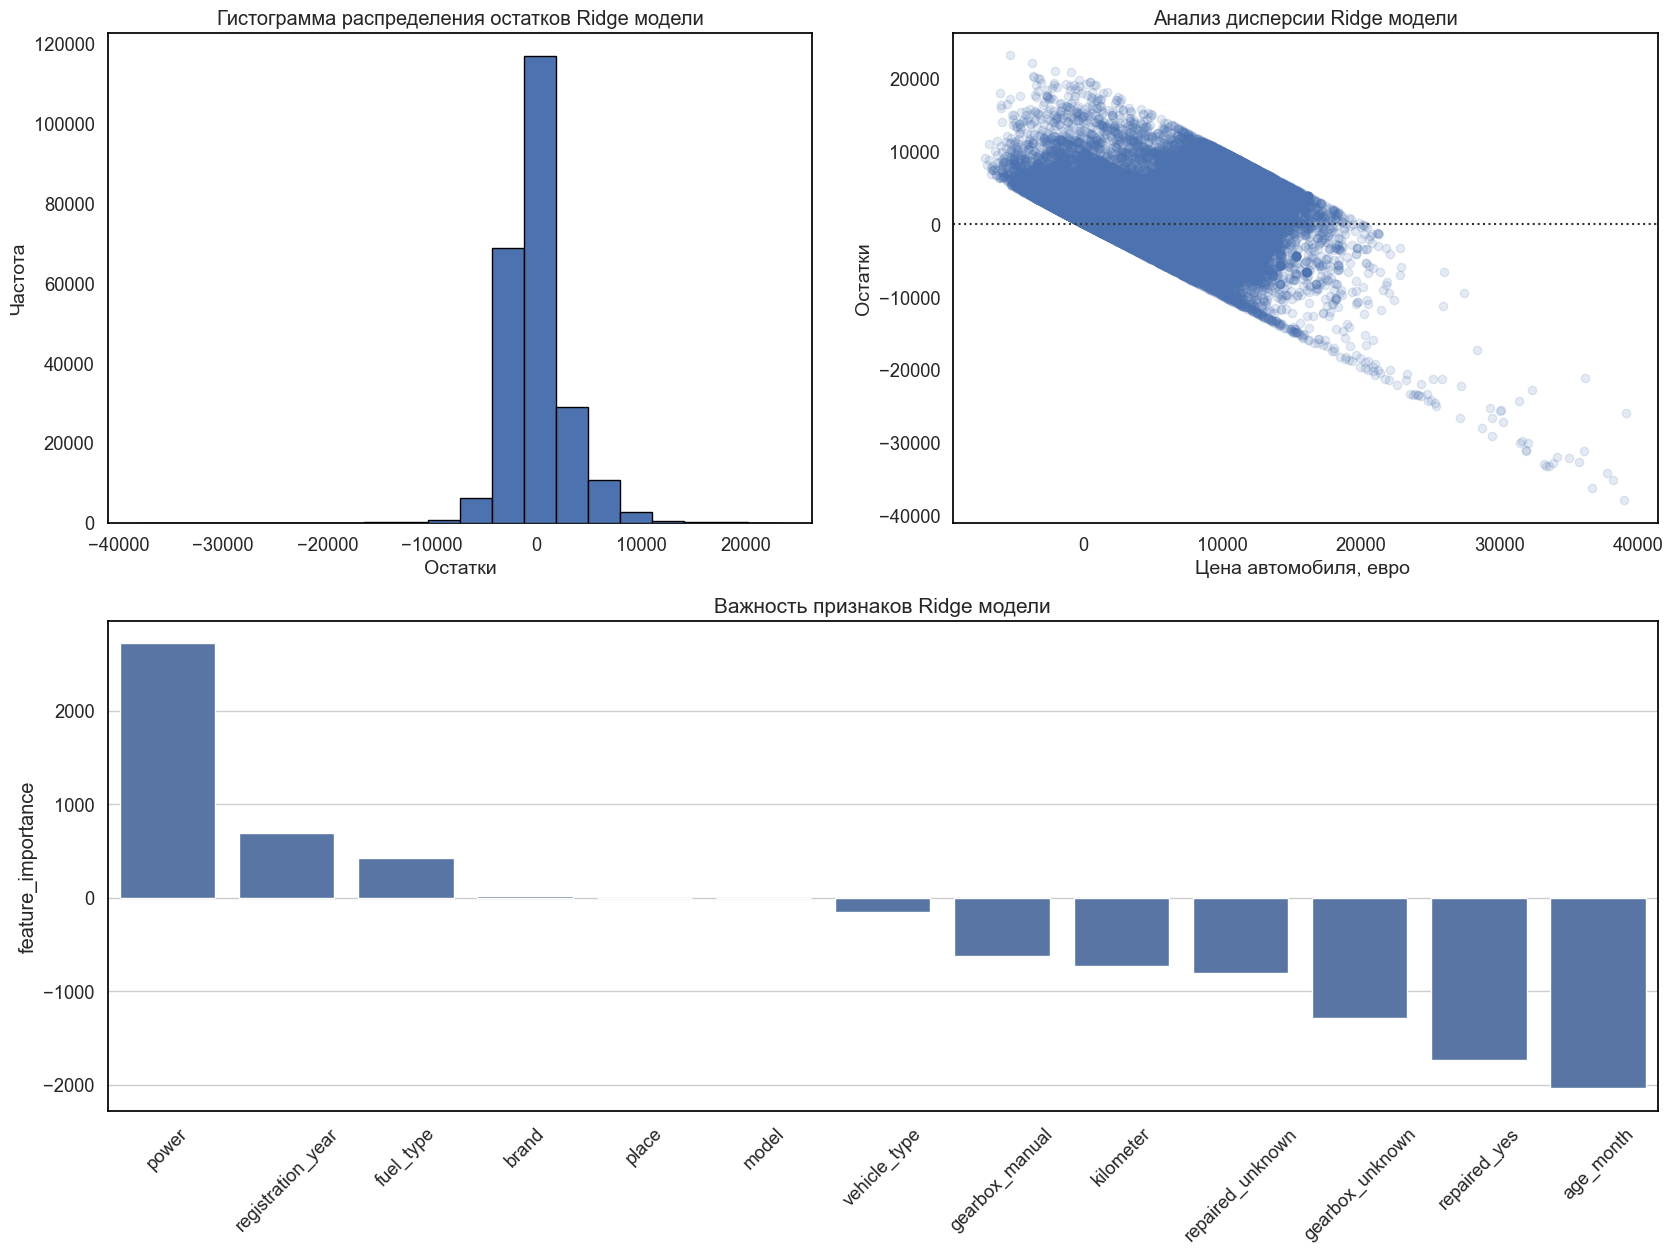

In [76]:
model_analysis(model_ridge)

- Ridge
- Остатки распределены нормально с небольшим смещением влево и малым процентом выбросов
- Есть гетероскедастичность, особенно в области больше 10 тыс евро, так как таргет сильно завязан на мощность двигателя и возраст и плохо учитываются мультикатегориальные признаки. Есть сильные выбросы в области высоких цен

### DecisionTree

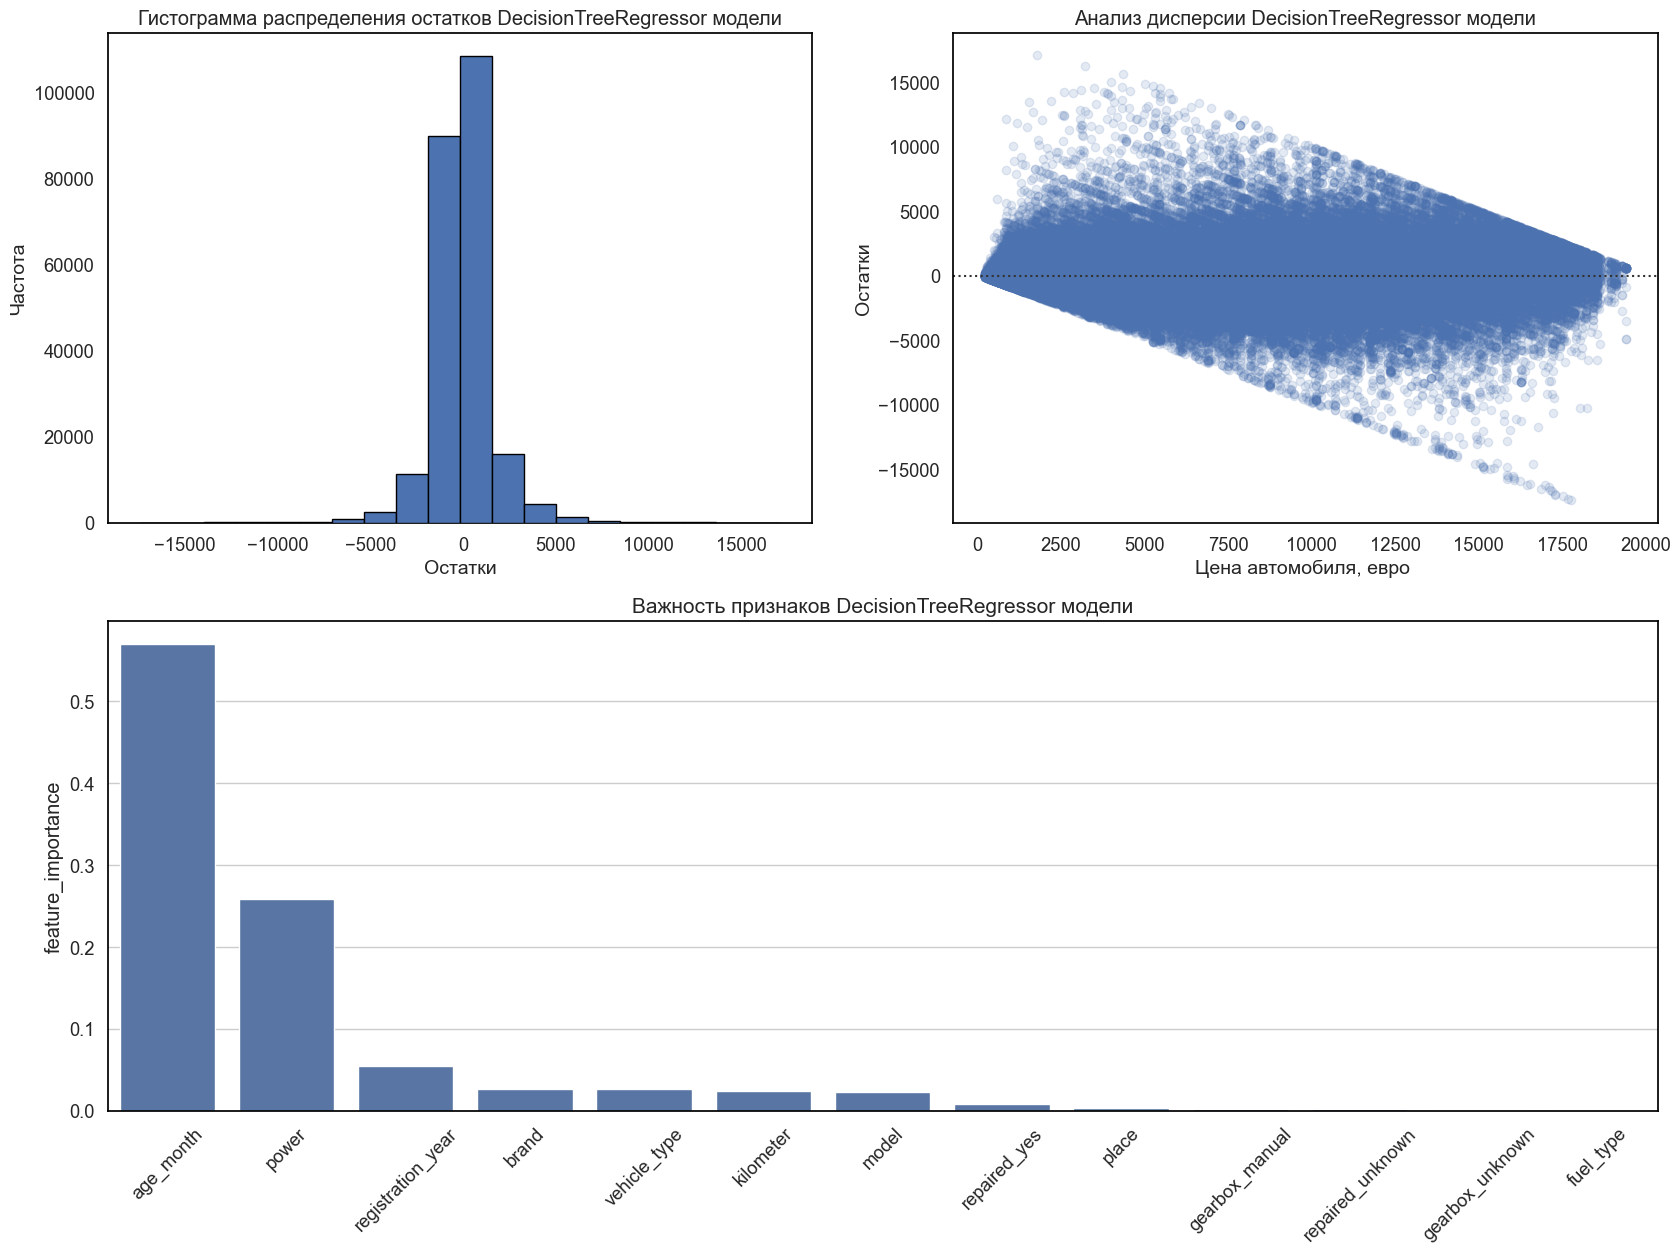

In [77]:
model_analysis(model_tree)

- DecisionTree
- Остатки распределены нормально
- В целом распределение гомоскедастично, есть выбросы в области низких цен (модель здесь занижает иногда), и в области высоких цен (иногда модель завышает)
- Самые важные признаки - возраст в месяцах и в два раза меньше - мощность двигателя

### RandomForest

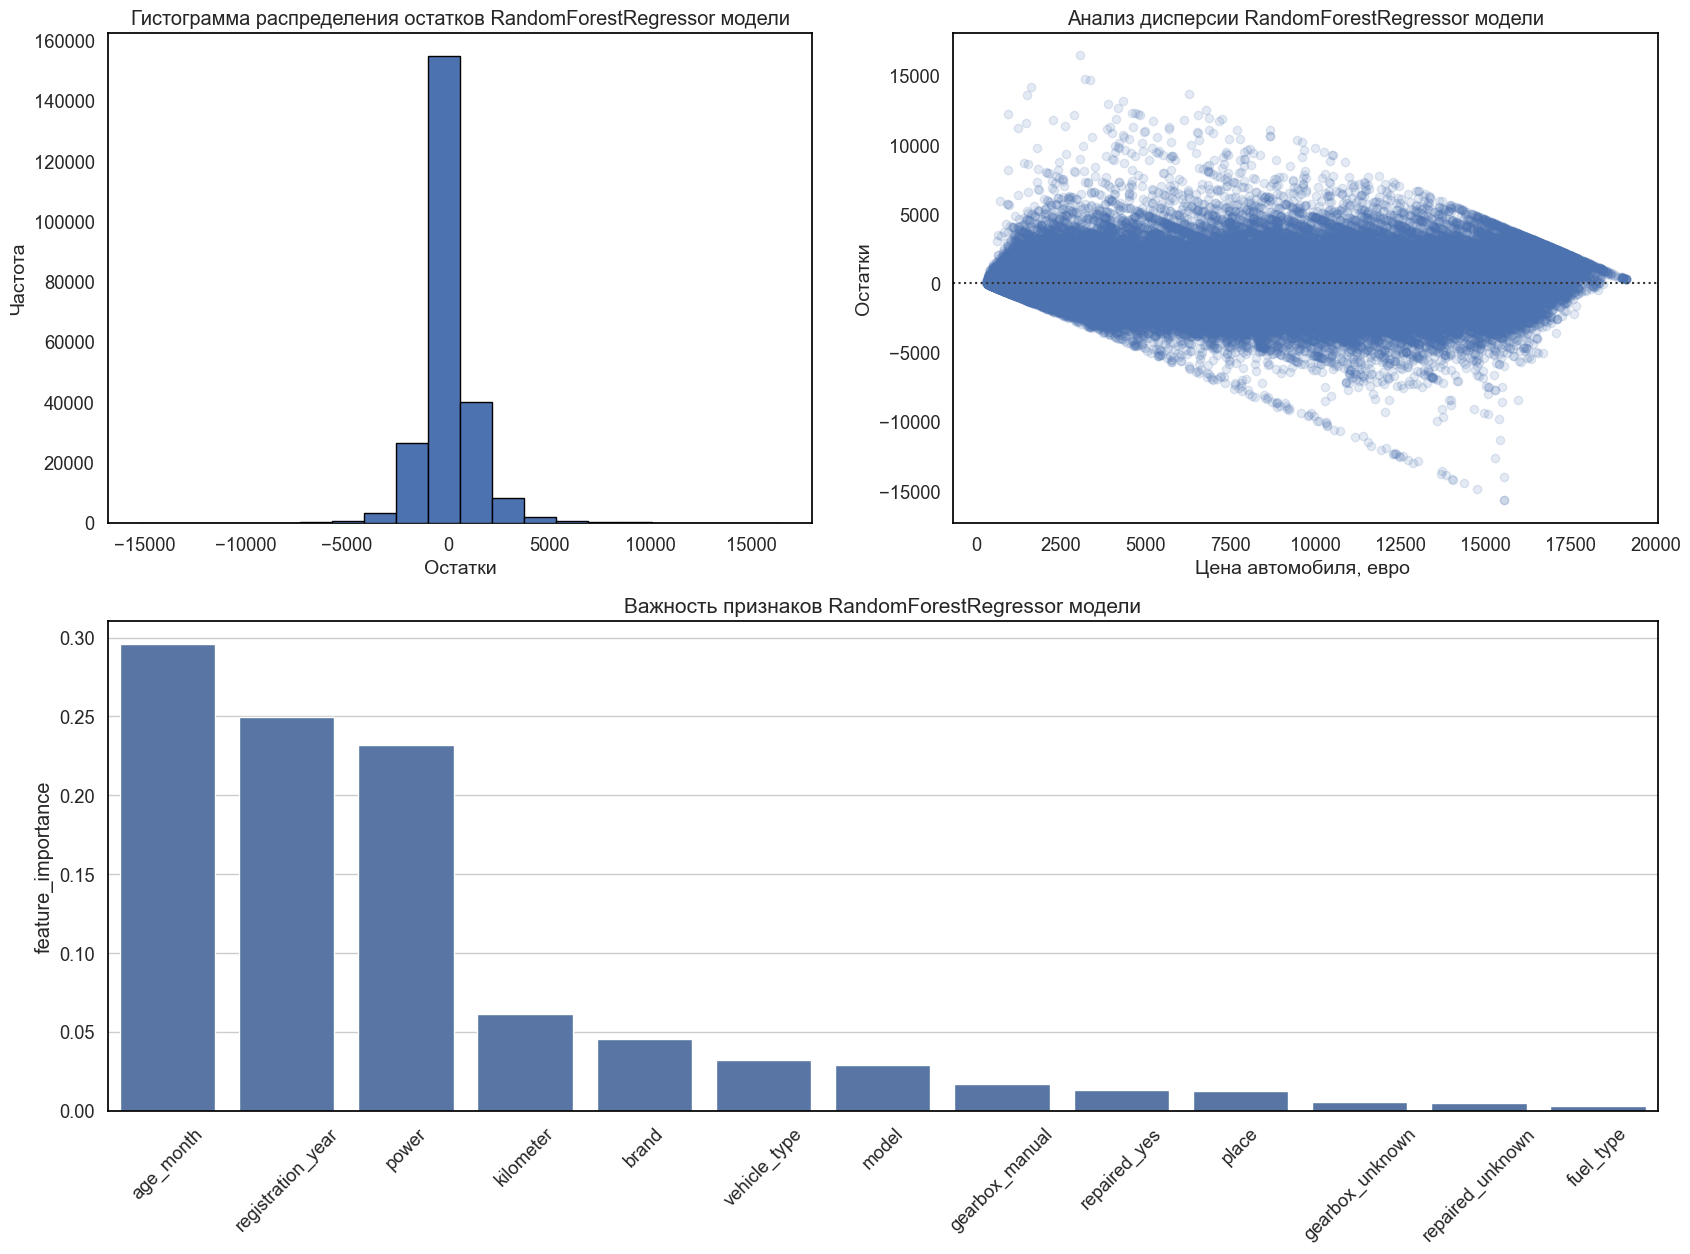

In [78]:
model_analysis(model_forest)

- RandomForest
- Остатки распределены нормально
- В целом распределение гомоскедастично, есть выбросы в области низких цен (модель здесь занижает иногда), и в области высоких цен (иногда модель завышает), но их количество меньше, в обычном дереве
- Самые важные признаки - возраст в месяцах, год регистрации и мощность двигателя. Но здесь уже более равномерно они распределены по значимости

### LGBM

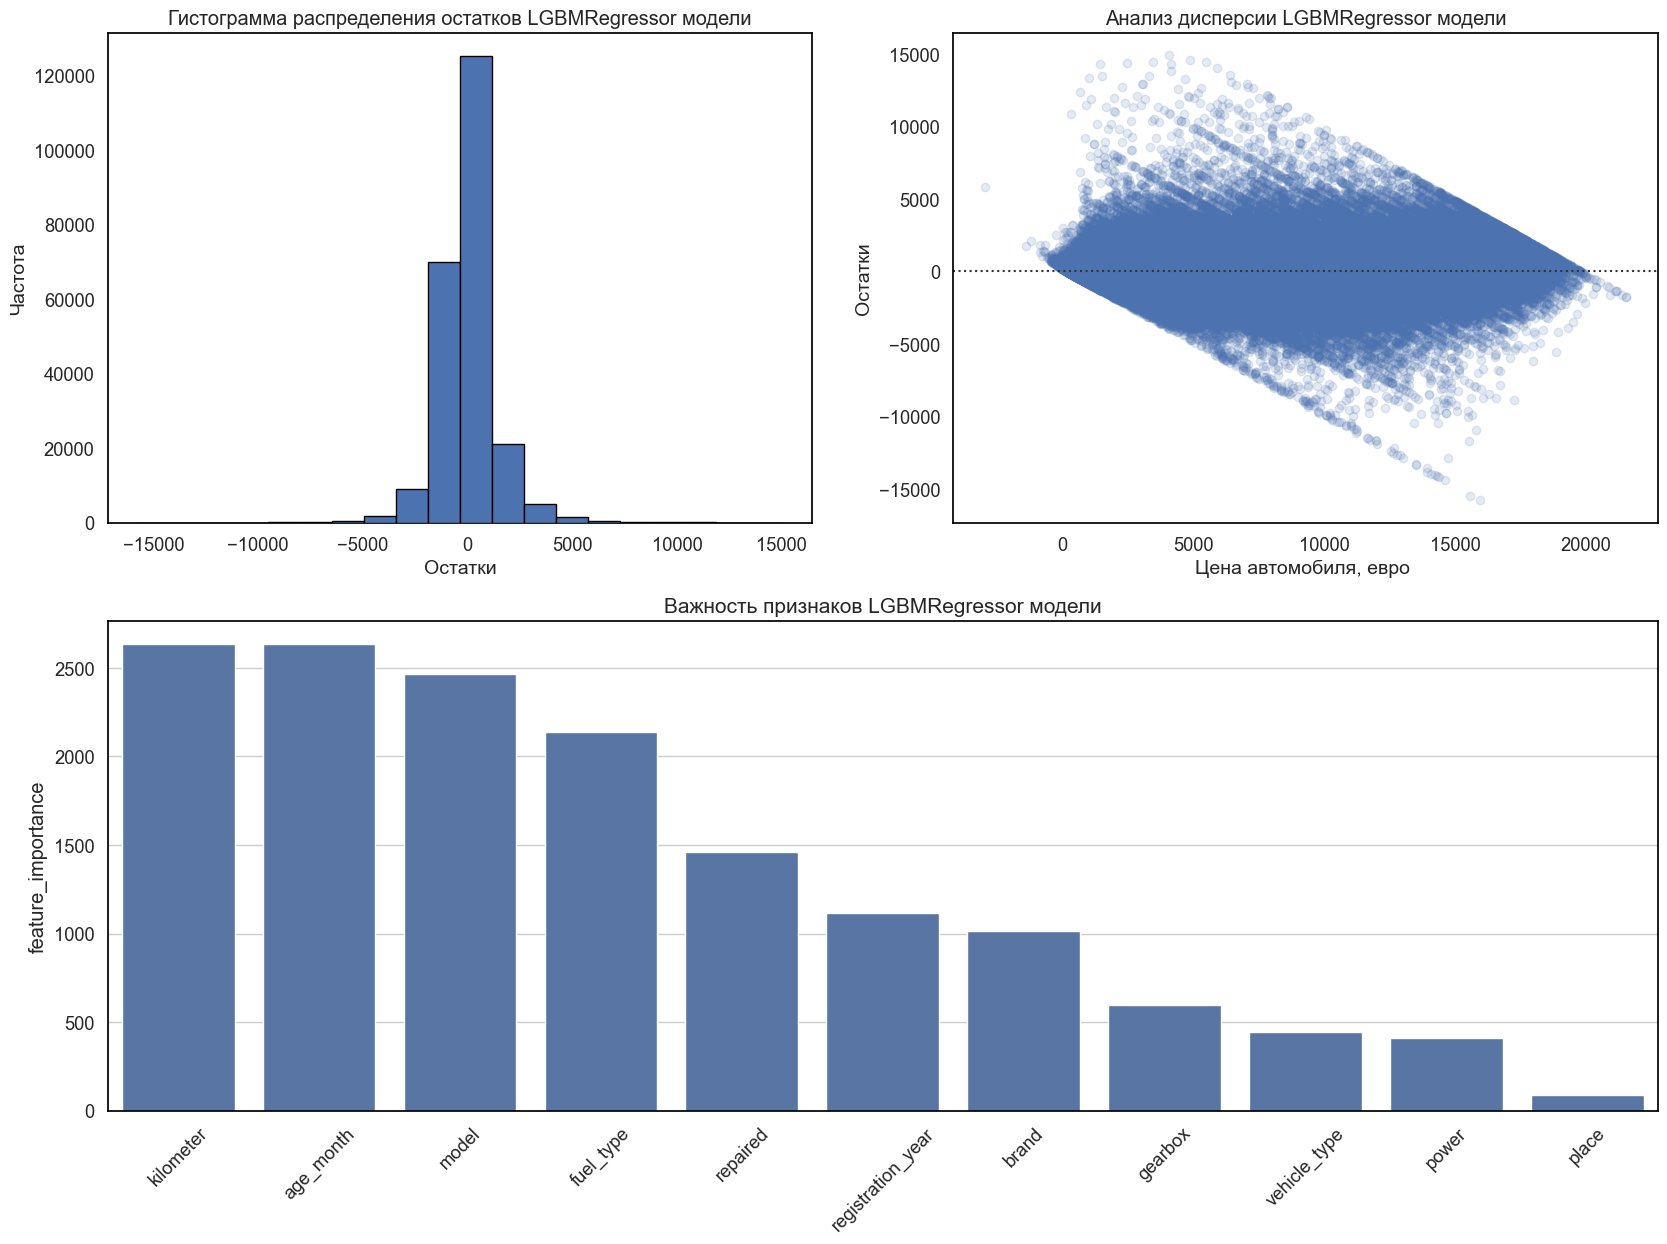

In [79]:
model_analysis(model_lgbm)

- LGBM
- Остатки распределены нормально
- В целом распределение гомоскедастично, есть выбросы, но немного меньше, чем в RandomForeste
- Самые важные признаки - пробег, возраст в месяцах, модель, типо топлива и ремонт. Картина совершенно поменялась, в отличие от предыдущих вариантов

### CatBoost

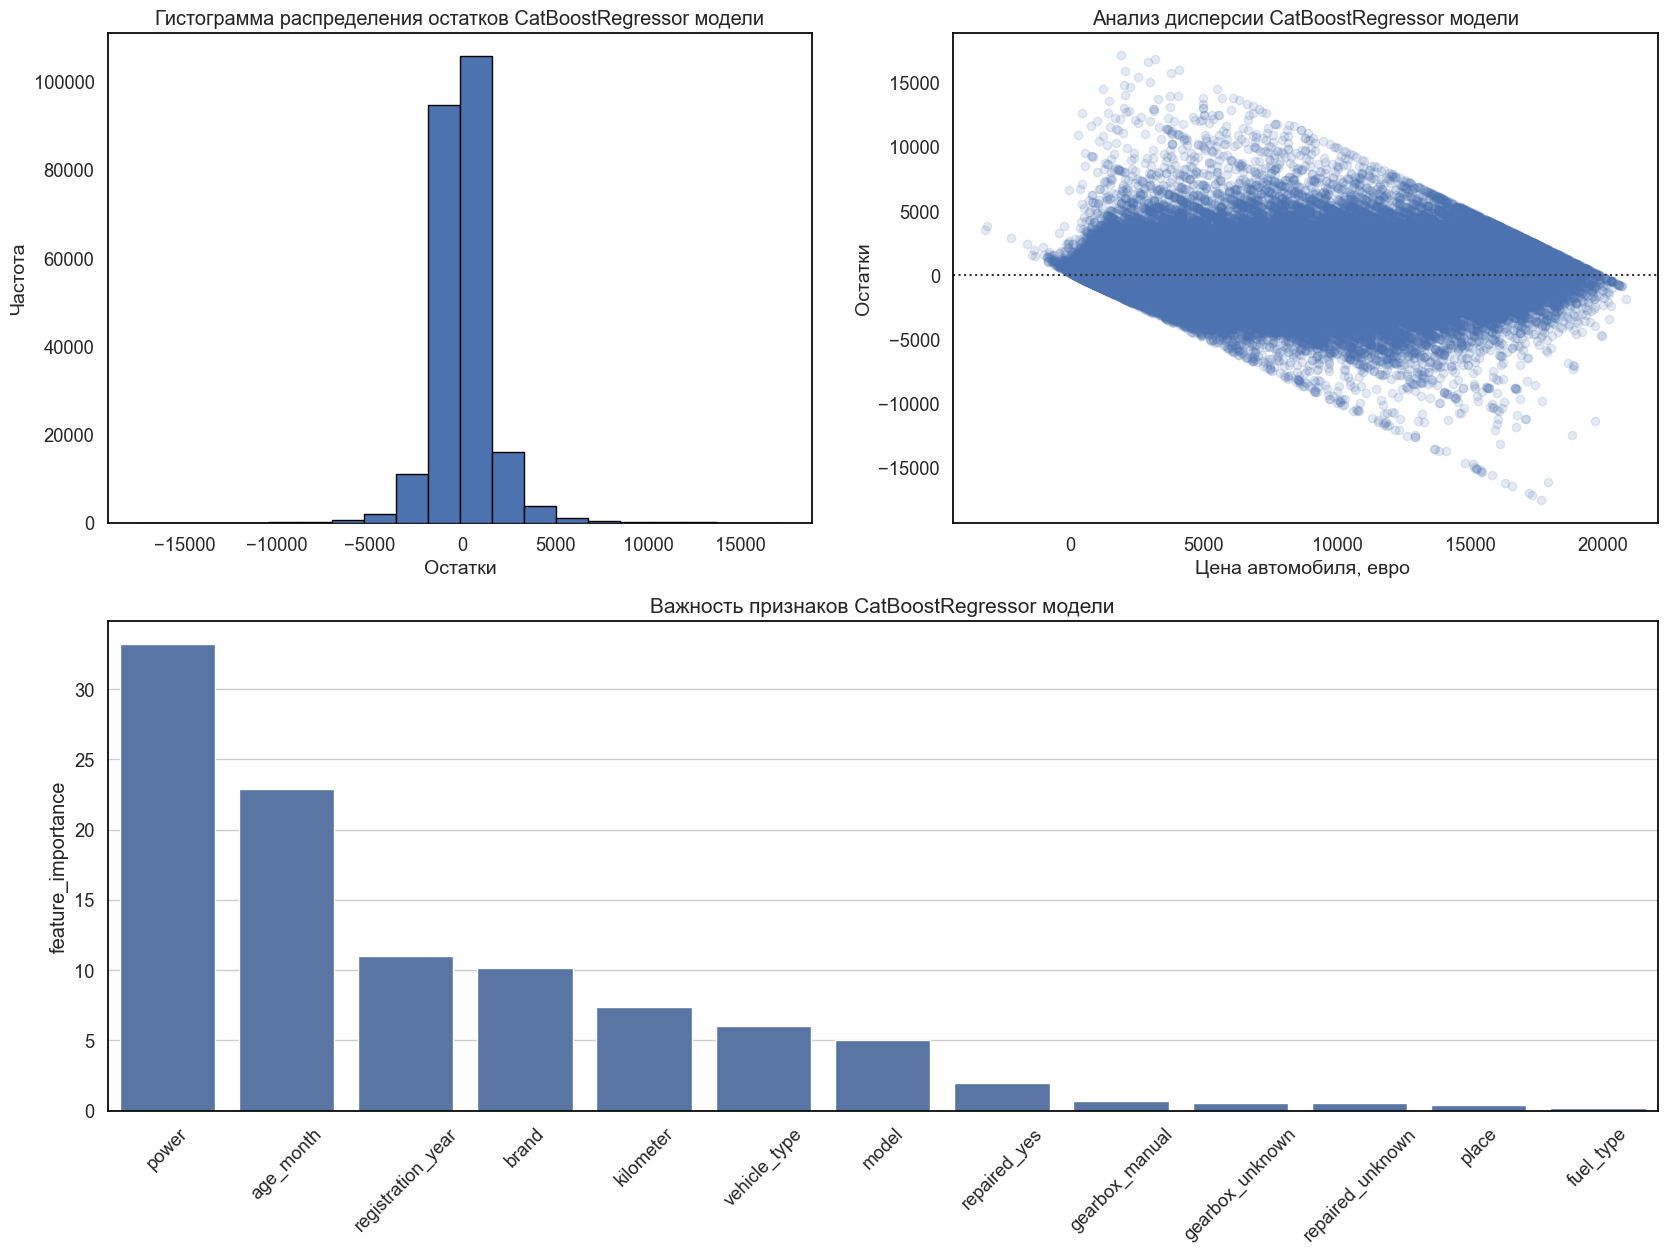

In [80]:
model_analysis(model_catboost)

- CatBoost
- Остатки распределены нормально
- В целом распределение гомоскедастично, есть выбросы, появились отрицательные стоимости авто :/
- Самые важные признаки - мощность, возраст, бренд - ближе к предыдущим вариантам обычного дерева и случайного леса

### Сравнение метрик моделей

In [81]:
comparison = pd.DataFrame({key: [res_ridge[key], 
                                 res_tree[key], 
                                 res_forest[key], 
                                 res_lgbm[key], 
                                 res_catboost[key]] for key in res_ridge})
comparison = comparison.sort_values(by='train_rmse')

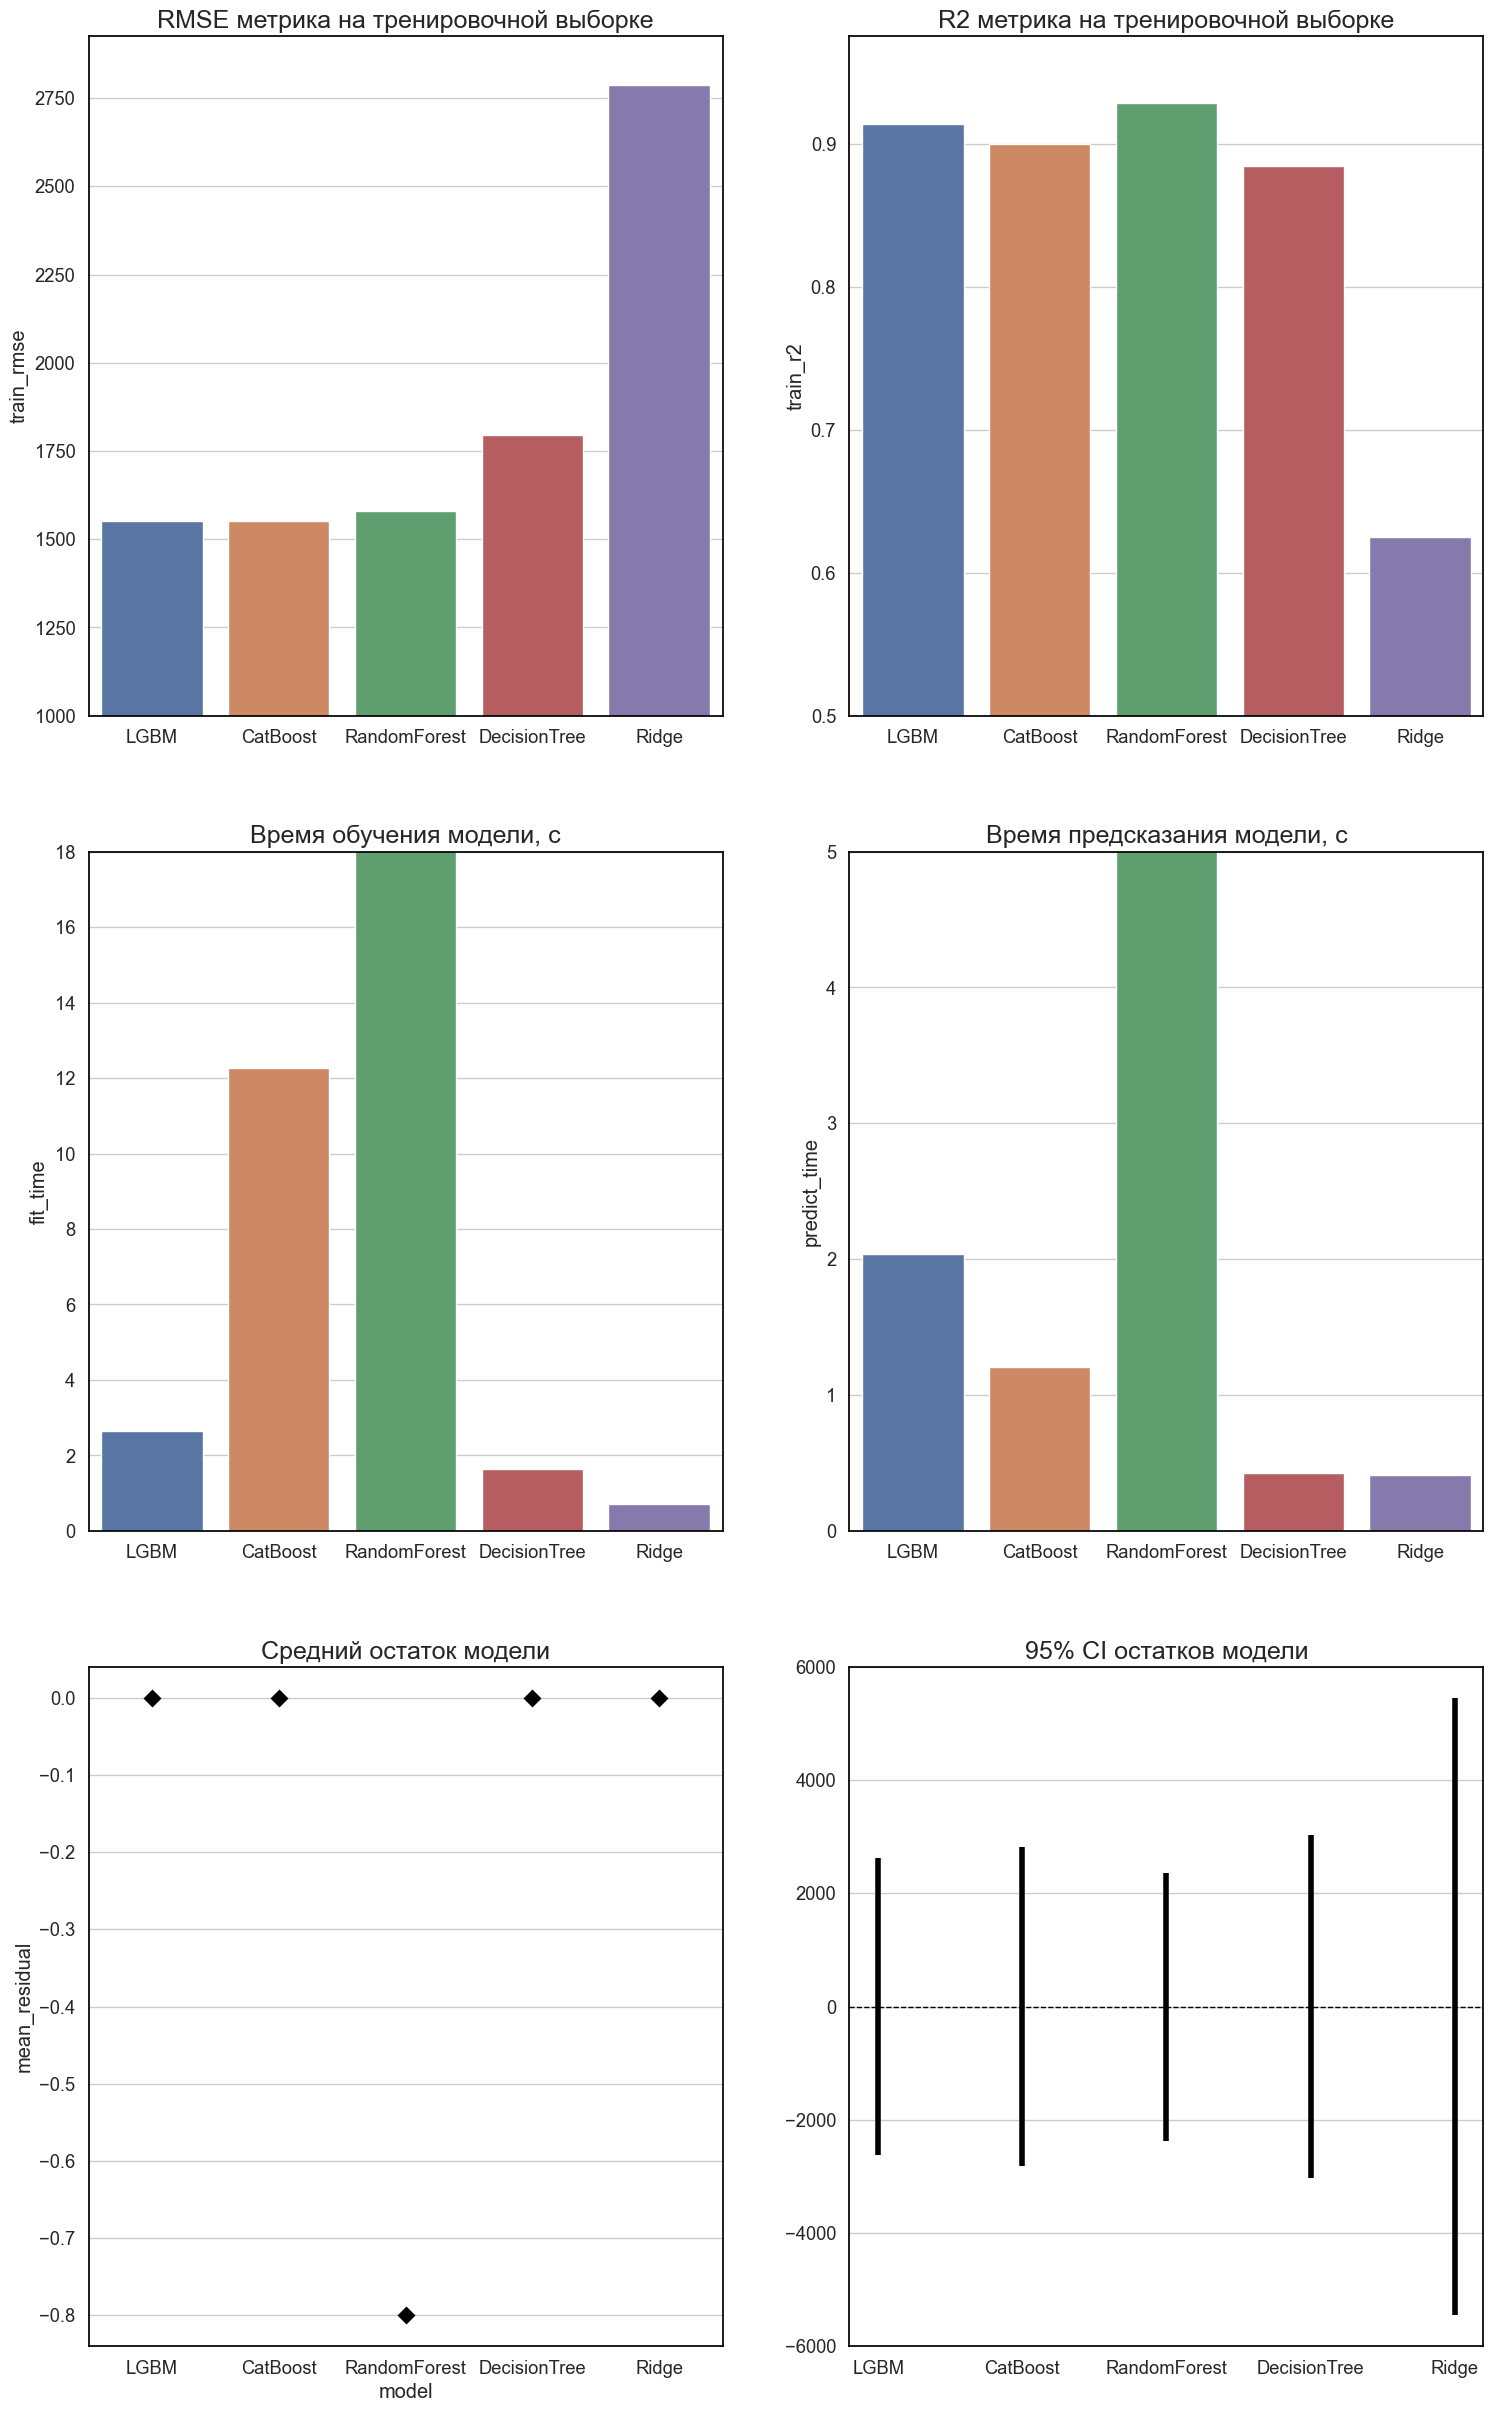

In [82]:
titles = [
          'RMSE метрика на тренировочной выборке',
          'R2 метрика на тренировочной выборке',  
          'Время обучения модели, с',
          'Время предсказания модели, с'
         ]
fig, ax = plt.subplots(3, 2, figsize=(18,30))
for idx, col in enumerate(comparison.iloc[:,1:-2]):
    bar = sns.barplot(data=comparison, 
                      x='model', 
                      y=col,
                      hue='model',
                      ax=ax[idx//2][(idx+2)%2])
    bar.set_title(f'{titles[idx]}', fontsize=18)
    bar.set_xlabel('')
    
sns.pointplot(data=comparison, 
              x='model', 
              y='mean_residual', 
              linestyle="none", 
              marker="D",
              color='black',
              ax=ax[2][0]).set_title('Средний остаток модели', fontsize=18)

ci_stat = np.array(comparison['residuals_95%_CI'].tolist()).T
ci_stat[0,:] *= -1
ax[2,1].errorbar(x=comparison['model'], y=np.zeros(5), 
             color='black', fmt='none', yerr=ci_stat, linewidth=4)
ax[2,1].set_xlabel('')
ax[2,1].grid(axis='x')
ax[2,1].axhline(y=0, linestyle='--', color='black', linewidth=1)
ax[2,1].set_title('95% CI остатков модели', fontsize=18)

ax[0,0].set_ylim(bottom=1000)
ax[0,1].set_ylim(bottom=0.5)
ax[1,0].set_ylim(0, max(comparison['fit_time'])//4)
ax[1,1].set_ylim(0, max(comparison['predict_time'])//2)
comparison

- RMSE метрика
    - По метрике сразу отпадает `Ridge` модель, хоть она и обучается и быстрее всех, но зависимости здесь сложные из-за мультикатегориальных признаков. Далее рассматривать ее не будем
    - Три вида моделей `LGBM`, `Catboost` (1552) и `RandomForest` (1579) показали очень близкие результаты - около 1560, но лучше всех - LGBM с результатом 1550
    - Обычное дерево решений тоже прошло порог заказчика с запасом и не так иж и далеко отстает от предыдущих моделей - 1796
 
 
- Время обучения
    - Хуже всех - `RandomForest` - 84.8 с
    - Заметно лучше `Catboost` - 11.1 c
    - И сильно лучше - `LGBM` и `DecisionTree`, 2.2 и 1.9 с соответственно


- Время предсказания
    - `RandomForest` опять хуже всех - 11.4 с
    - Примерно близкие результаты показывают 
        - `LGBM` - 1.5 c
        - `CatBoost` - 1.2 c
        - `DecisionTree` - 0.5 c


- R2 метрика
    - `RandomForest` заметно лучше других на тренировочной выборке - 0.929
    - `DecisionTree` - 0.885
    - `CatBoost` и `LGBM` показывают себя более стабильно (0.900) и (0.914) соответственно
    

- 95% CI
    - `DecisionTree` - [-3029.0, 3029.0]
    - `Catboost` - [-2814.0, 2814.0]
    - `LGBM` - [-2622.0, 2622.0]
    - `RandomForest` - [-2369.0, 2368.0]   

In [83]:
print('RMSE LGBM модели на тестовой выборке', round(root_mean_squared_error(y_test, model_lgbm.predict(X_test))))

### Вывод

- Было обучено четыре вида моделей: 
    - Линейная регрессия - Ridge
    - Дерево решений - DecisionTreeRegressor
    - Случайный лес - RandomForestRegressor
    - Градиентный Бустинг - LGBM и CatBoost


- **Лучшей по условиям заказчика будет LightGBM, так как:**
    - Лучшая RMSE - **1550**
    - Обучается быстрее Catboost с почти такой же RMSE (**2 секунды** против 11), в поиске модели это проявится сильнее, а также при кратном увеличении выборки
    - Предсказывает быстро, чуть медленнее, чем CatBoost (**1.5 секунды** против 1.2), но сравнимо
    - Интересно, что расставил признаки так, как думает обычный пользователь, по крайней мере я:
        - Больше всего на цену влияет пробег, так как он явный маркер изношенности авто
        - Затем возраст авто, так как молодые авто могут быть с очень большим пробегом
        - Далее модель, тип топлива - износ двигателя и его дорогвизна
        - Была ли в ремонте
- 95 % СI остатков у LGBM на 200 меньше, чем у CatBoost
- **RMSE метрика LGBM модели на тестовой выборке - 1529**

## Общий вывод

В результате данного исследования на основе исторических данных о технических характеристиках, комплектации и ценах автомобилей в сервисе заказчика были созданы пять моделей по предсказанию стоимости автомобиля - Linear Regression, Decision Tree, Random Forest, LGBM и CatBoost. По указанным требованиям заказчика **лучшей моделью оказалась LGBM** с метрикой RMSE **1550** на тренировочной выборке и **1529** на тестовой выборке, временем обучения и предсказания около 2.2 секунды каждое (на Ryzen 4000 Series 5 и 24 Gb оперативной памяти).


- **Исходные данные** 
    - 354369 записей
    - пропуски
        - `repaired` - 20.1 %
        - `vehicle_type` - 10.6 %
        - `fuel_type` - 9.3 %
        - `gearbox` - 5.6 %
        - `model` - 5.6 %
    - неявные дубликаты
        - `gasoline` и `petrol` в `fuel_type`


- **Иследовательский анализ**
    - Выбросили 4 полных дубликата
    - Выбросили столбцы из-за неинформативности
        - `number_of_pictures`
        - `last_seen`
        - `date_crawled`
        - `date_created`
    - В `fuel_type` объединили `petrol` и `gasoline` в `petrol`, так как это одно и то же
    - Признак `postal_code` заменили на `place` с 397 уникальными областями Германии с помощью `pgeocode`
    - По целевому признаку `price` убрали 14300 записей с ценой авто менее 100 евро
    - 26 тыс. 0 в `registration_month` (когда месяц был 0) равномерно заполнили случайными значениями от 1 до 12
    - По `registration_year` и `registration_month` выбросили около 19 тыс. объектов после апреля 2016 года, так как на эту дату происходила выгрузка. Так же убрали объекты до 1980 года, так как в зоне ретро авто 
    - Добавили `age_month` как возраст авто в месяцах
    - Мощность двигателя `power` ограничили сверху 1000, а снизу 35 л.с. Около 29 тыс. 0 значений заполнили медианой с помощью группировки по `brand`, `model`, `vehicle_type`, `registration_year`. Около 2000 записей выбросили, так как не нашлось полных групп
    - Пропуски (около 50 тыс. суммарно) в `model`, `vehicle_type`, и `fuel_type` заполнили с помощью `MissForest` подхода через `IterativeImputer` и `RandomForestClassifier`
    - Около 10 % выброшенных записей так или иначе были сильно связаны с целевым признаком и не представляли возможным точно определить некорректность их значений


- **Обучение моделей**
    - Было обучено 5 моделей: 
        - Линейная регрессия - `Ridge`
        - Дерево решений - `DecisionTreeRegressor`
        - Случайный лес - `RandomForestRegressor`
        - Градиентный Бустинг - `LGBM` и `CatBoost`
    - Подбор гиперпараметров осуществлялся с помощью RandomizedSearchCV с кросс-валидацией из 3 подвыборок
    - Время предсказания усреднялось по трем попыткам. Время обучения не усреднялось ввиду экономии ресурсов

- **Анализ моделей**
    - RMSE метрика  
        - `LGBM` - 1550 
        - `Catboost` - 1552 
        - `RandomForest` - 1579
        - `DecisionTree` - 1796
        - `Ridge` показала наихудший результат - 2786. Далее не рассматривалась
    - Время обучения
        - Хуже всех - `RandomForest` - 84.8 с
        - Заметно лучше `Catboost` - 11.1 c
        - И сильно лучше - `LGBM` и `DecisionTree`, 2.2 и 1.9 с соответственно
    - Время предсказания
        - `RandomForest` опять хуже всех - 11.4 с
        - Примерно близкие результаты показывают 
            - `LGBM` - 1.5 c
            - `CatBoost` - 1.2 c
            - `DecisionTree` - 0.5 c
    - R2 метрика
        - `RandomForest` заметно лучше других на тренировочной выборке - 0.929
        - `DecisionTree` - 0.885
        - `CatBoost` и `LGBM` показывают себя более стабильно (0.900) и (0.914) соответственно
    - 95% CI
        - `DecisionTree` - [-3029.0, 3029.0]
        - `Catboost` - [-2814.0, 2814.0]
        - `LGBM` - [-2622.0, 2622.0]
        - `RandomForest` - [-2369.0, 2368.0]     
        

- Лучшая модель по условиям заказчика - **LGBMRegressor**:
    - Лучшая RMSE - **1550** на тренировочной выборке
    - Обучается быстрее Catboost с почти такой же RMSE (**2 секунды** против 12), в поиске модели это проявится сильнее, а также при кратном увеличении выборки
    - Предсказывает быстро, чуть медленнее, чем CatBoost (**2.28 секунды** против 1.55), но сравнимо
    - Интересно, что расставил признаки так, как думает обычный пользователь, по крайней мере я:
        - Больше всего на цену влияет пробег, так как он явный маркер изношенности авто
        - Затем возраст авто, так как молодые авто могут быть с очень большим пробегом
        - Далее модель, тип топлива - износ двигателя и его дорогвизна
        - Была ли в ремонте
    - Остатки у LightGBM распределены нормально, есть небольшой процент выбросов - недооценивает дешевые авто и переоценивает дорогие
    - **RMSE метрика LGBM модели на тестовой выборке - 1529**

- **Возможные улучшения модели**
    - Без заполнения пропусков можно снизить RMSE где-то до 1500
    - Попробовать выяснить что за выбросы появляются в предсказаниях - скорее всего в области очень старых авто и совсем новых, из-за перевыпусков моделей
    - Попробовать не выбрасывать группы объектов, а заменить некорректные значения пропусками
    - Сузить возраст автомобилей сильнее

- **Рекомендации заказчику**
    - Во время тестирования использовать на группах клиентов LGBM и CatBoost модели, так как у них различаются важности признаков
    - Более стандартизированный подход для новых объявлений, так как модель будет менее точно предсказывать стоимость автомобиля, если пользователь не заполнит какое-либо из значимых полей, например мощность двигателя
    - Предупредить пользователей из соответствующих групп, что для ретро-авто и очень дорогих редких автомобилей модель может работать с очень большой погрешностью